# Extreme Value Analysis Tutorial

This notebook demonstrates how to use the `ExtremesAnalyzer` class for extreme value analysis, including return period calculations, block maxima extraction, and Peaks Over Threshold (POT) analysis.

## Overview

`ExtremesAnalyzer` is designed to:
- Calculate return periods and return values for extreme events
- Extract block maxima (annual, monthly, seasonal)
- Perform Peaks Over Threshold (POT) analysis with declustering
- Fit extreme value distributions (GEV, Gumbel, Weibull, GPD)
- Visualize return level plots
- Handle flexible time series formats (pandas, datetime64, numeric arrays)

## Setup and Data Generation

Let's start by importing the necessary libraries and generating sample wind speed data using MagicA's synthetic data generator.

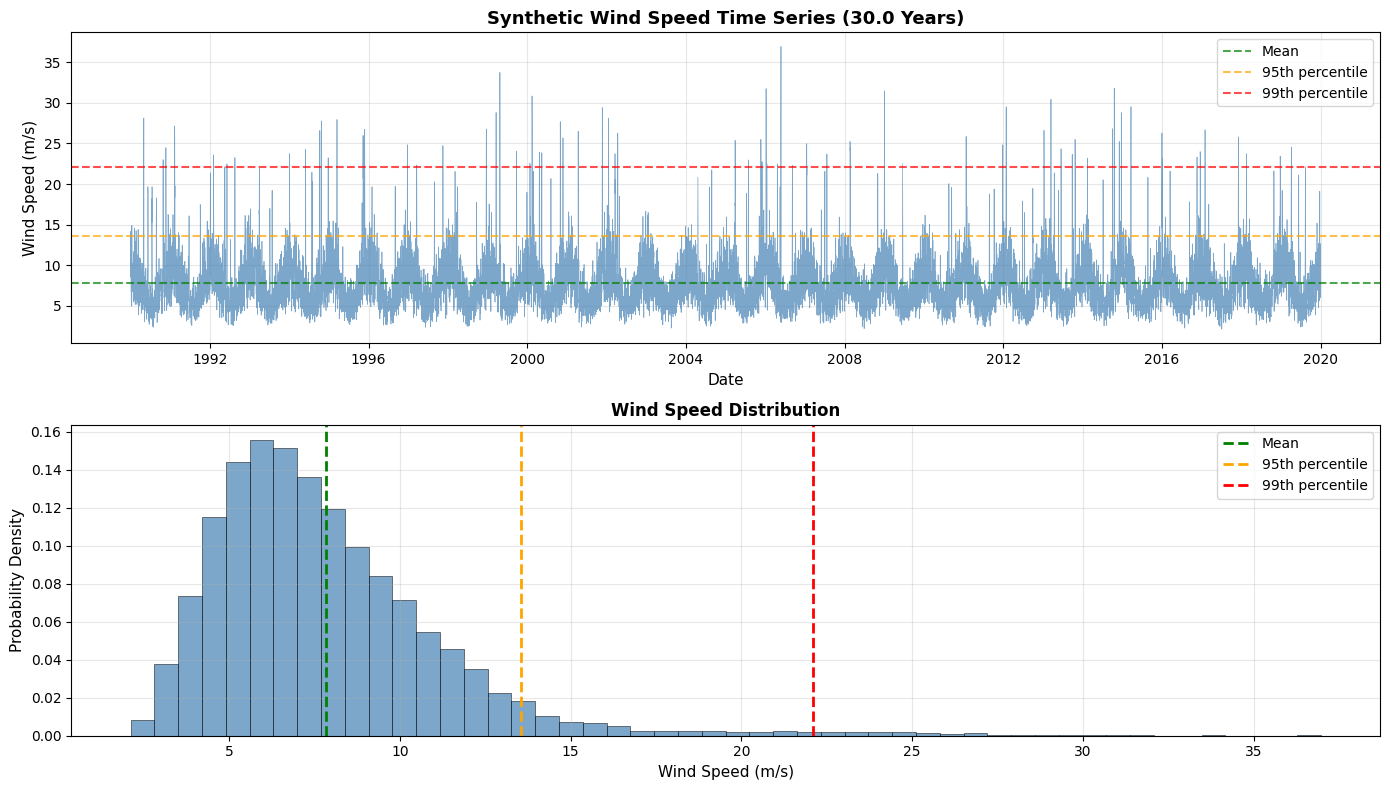

Generated 10957 daily wind speed measurements (30.0 years)
Date range: 1990-01-01 to 2019-12-31
Min: 2.11 m/s
Max: 36.96 m/s
Mean: 7.82 m/s
Std: 3.48 m/s
95th percentile: 13.55 m/s
99th percentile: 22.09 m/s

💡 Data generated using MagicA's generate_wind_data() function


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import magica as ma
from magica.utils import generate_wind_data

# Generate 30 years of daily wind speed data using MagicA
wind_series, plots = generate_wind_data(
    n_years=30,
    freq='D',
    mean_wind=8.0,
    weibull_shape=2.5,
    seasonal_amplitude=0.3,
    n_storms_per_year=5,
    storm_duration_range=(2, 5),
    storm_intensity_range=(12, 20),
    random_seed=42,
    create_plots=True
)

# Display the plots
plt.show()

# Get basic statistics
dates = wind_series.index
wind_speeds = wind_series.values

print(f"Generated {len(wind_series)} daily wind speed measurements ({len(dates)/365:.1f} years)")
print(f"Date range: {dates[0].date()} to {dates[-1].date()}")
print(f"Min: {wind_speeds.min():.2f} m/s")
print(f"Max: {wind_speeds.max():.2f} m/s")
print(f"Mean: {wind_speeds.mean():.2f} m/s")
print(f"Std: {wind_speeds.std():.2f} m/s")
print(f"95th percentile: {np.percentile(wind_speeds, 95):.2f} m/s")
print(f"99th percentile: {np.percentile(wind_speeds, 99):.2f} m/s")
print(f"\n💡 Data generated using MagicA's generate_wind_data() function")



## Visualizing the Time Series

Let's look at the complete time series and identify extreme events.

## Basic Usage: Creating an ExtremesAnalyzer

The `ExtremesAnalyzer` can be created from a `DataProcessor` using the `get_extremes_analyzer()` method. It automatically handles pandas Series with datetime indices.

In [2]:
# Load data using MagicA's DataProcessor
# The pandas Series with datetime index will be automatically preserved
processor = ma.read_data(wind_series)
print(f"Loaded data: {processor}")

# Create ExtremesAnalyzer (time_unit='years' for return periods in years)
extremes = processor.get_extremes_analyzer(time_unit='years')
print(f"\nCreated ExtremesAnalyzer: {extremes}")

# Check the time span
print(f"Time span: {extremes.time_span:.2f} years")
print(f"Number of observations: {len(extremes.data)}")

Loaded data: DataProcessor(length=10957, dtype=float64)

Created ExtremesAnalyzer: ExtremesAnalyzer(n_points=10957, time_span=30.0 years)
Time span: 30.00 years
Number of observations: 10957


## Block Maxima Approach: Generalized Extreme Value (GEV) Distribution

The Block Maxima method extracts the maximum value from fixed time blocks (e.g., annual maxima) and fits a GEV distribution. This is the classical approach in extreme value theory.

In [3]:
# Extract annual maxima
annual_maxima, years = extremes.extract_block_maxima(block_size='YE', method='max')
print(f"Annual Maxima Analysis:")
print(f"Number of years: {len(annual_maxima)}")
print(f"\nAnnual maximum wind speeds:")
for year, max_wind in zip(years, annual_maxima):
    print(f"  {year.year}: {max_wind:.2f} m/s")
print(f"\nStatistics of annual maxima:")
maxima_values = list(annual_maxima)
print(f"Mean: {np.mean(maxima_values):.2f} m/s")
print(f"Std: {np.std(maxima_values):.2f} m/s")
print(f"Min: {np.min(maxima_values):.2f} m/s")
print(f"Max: {np.max(maxima_values):.2f} m/s")

Annual Maxima Analysis:
Number of years: 30

Annual maximum wind speeds:
  1990: 28.12 m/s
  1991: 27.15 m/s
  1992: 23.58 m/s
  1993: 21.92 m/s
  1994: 27.78 m/s
  1995: 27.95 m/s
  1996: 24.83 m/s
  1997: 24.74 m/s
  1998: 26.78 m/s
  1999: 33.76 m/s
  2000: 30.86 m/s
  2001: 29.43 m/s
  2002: 28.12 m/s
  2003: 16.50 m/s
  2004: 21.75 m/s
  2005: 25.50 m/s
  2006: 36.96 m/s
  2007: 24.97 m/s
  2008: 25.25 m/s
  2009: 31.48 m/s
  2010: 20.04 m/s
  2011: 25.87 m/s
  2012: 29.53 m/s
  2013: 30.45 m/s
  2014: 31.82 m/s
  2015: 29.54 m/s
  2016: 26.29 m/s
  2017: 26.69 m/s
  2018: 23.72 m/s
  2019: 24.56 m/s

Statistics of annual maxima:
Mean: 26.86 m/s
Std: 4.08 m/s
Min: 16.50 m/s
Max: 36.96 m/s


In [4]:
# Create a new processor with annual maxima
maxima_processor = ma.read_data(np.array(maxima_values))

# Instead of assuming a distribution, let's test several
# common extreme value distributions using AutoFitter
print("Testing multiple extreme value distributions...")
print("=" * 70)

# Define distributions commonly used for extreme values
extreme_distributions = [
    'genextreme',      # Generalized Extreme Value (GEV) - most general
    'gumbel_r',        # Gumbel (Type I) - special case of GEV
    'weibull_min',     # Weibull - commonly used for wind extremes
    'weibull_max',     # Weibull maximum
    'lognorm',         # Log-normal - sometimes used for extremes
    'gamma',           # Gamma distribution
    'exponweib'        # Exponentiated Weibull
]

# Create AutoFitter with extreme value distributions
auto_fitter = maxima_processor.get_auto_fitter(
    candidates=extreme_distributions,
    criterion='rmse'  # Use RMSE as primary criterion
)

# Find best distribution
print("\nFitting distributions to annual maxima...\n")
best_result = auto_fitter.fit_best_distribution()

print(f"Best Distribution: {best_result.name}")
print(f"RMSE: {best_result.goodness_of_fit('rmse'):.6f}")
print(f"AIC: {best_result.goodness_of_fit('aic'):.2f}")
print(f"BIC: {best_result.goodness_of_fit('bic'):.2f}")

# Use the best distribution for further analysis
best_dist_name = best_result.name

# Create ExtremesAnalyzer with the best fitted distribution
maxima_extremes = maxima_processor.get_extremes_analyzer()
maxima_extremes.fit_distribution(best_dist_name)

# Get fitted parameters
params = maxima_extremes.fitted_params
print(f"\n" + "=" * 70)
print(f"BEST DISTRIBUTION: {best_dist_name.upper()}")
print("=" * 70)
print(f"Fitted Parameters: {[round(param) for param in params]}")

# Evaluate goodness-of-fit for best distribution
gof = maxima_extremes.goodness_of_fit(method='ks')
print(f"\nGoodness-of-Fit Statistics:")
print(f"  KS Statistic: {gof['ks_statistic']:.4f}")
print(f"  P-value: {gof['p_value']:.4f}")
print(f"  Result: {'GOOD FIT ✓' if gof['p_value'] > 0.05 else 'POOR FIT ✗'} (α = 0.05)")

print(f"\n💡 The {best_dist_name} distribution provides the best fit to the annual maxima")
print(f"   based on RMSE criterion. This will be used for return value calculations.")

Testing multiple extreme value distributions...

Fitting distributions to annual maxima...

Testing 7 distributions...
  [1/7] Fitting genextreme...
  [2/7] Fitting gumbel_r...
  [3/7] Fitting weibull_min...
  [4/7] Fitting weibull_max...
  [5/7] Fitting lognorm...
  [6/7] Fitting gamma...
  [7/7] Fitting exponweib...
✓ All distributions fitted successfully
Best Distribution: gamma
RMSE: 0.032312
AIC: 175.48
BIC: 179.69

BEST DISTRIBUTION: GAMMA
Fitted Parameters: [7708, -331, 0]

Goodness-of-Fit Statistics:
  KS Statistic: 0.0869
  P-value: 0.9624
  Result: GOOD FIT ✓ (α = 0.05)

💡 The gamma distribution provides the best fit to the annual maxima
   based on RMSE criterion. This will be used for return value calculations.


/Users/danilocoutodesouza/anaconda3/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:2306: RuntimeWarning: invalid value encountered in add
  logp = (np.log(a) + np.log(c) + sc.xlogy(a - 1.0, exm1c) +
/Users/danilocoutodesouza/Documents/Programs_and_scripts/MagicA/magica/core/extremes_analyzer.py:267: UserWarning: No time information provided. Assuming uniform time spacing. Return periods will be in units of observation count.
  warnings.warn(


## Return Period and Return Value Analysis

Now let's calculate return values for different return periods (e.g., 10-year, 50-year, 100-year wind speeds).

**Important Note on Workflow:**
- When working with block maxima (e.g., annual maxima), each data point already represents one time unit (e.g., 1 year)
- The `ExtremesAnalyzer` can fit distributions directly using `fit_distribution()`
- No need to fit the distribution on the `DataProcessor` first
-  The `time_unit` parameter is mainly for the original time series, not for the extracted maxima

In [5]:
# Calculate return values for various return periods
# The maxima_extremes analyzer already has the fitted distribution
return_periods = [2, 5, 10, 20, 50, 100]

print("Return Period Analysis (Block Maxima / GEV):")
print("=" * 60)
print(f"{'Return Period':<20} {'Return Value (m/s)':<20} {'Design Use'}")
print("-" * 60)

for T in return_periods:
    rv = maxima_extremes.return_value(T)
    
    # Suggest design use based on return period
    if T <= 5:
        design_use = "Operational limits"
    elif T <= 25:
        design_use = "Standard structures"
    elif T <= 50:
        design_use = "Important structures"
    else:
        design_use = "Critical infrastructure"
    
    print(f"{T} years{'':<13} {rv:.2f}{'':<15} {design_use}")

print("\n💡 Interpretation:")
print("   A 50-year return value has a 2% probability of being exceeded in any given year.")
print("   Over a 50-year period, there's approximately a 63.4% chance of exceeding this value.")

Return Period Analysis (Block Maxima / GEV):
Return Period        Return Value (m/s)   Design Use
------------------------------------------------------------
2 years              26.85                Operational limits
5 years              30.29                Operational limits
10 years              32.10                Standard structures
20 years              33.60                Standard structures
50 years              35.29                Important structures
100 years              36.42                Critical infrastructure

💡 Interpretation:
   A 50-year return value has a 2% probability of being exceeded in any given year.
   Over a 50-year period, there's approximately a 63.4% chance of exceeding this value.


In [6]:
# Calculate return periods for specific wind speed thresholds
threshold_speeds = [22, 24, 26, 28]

print("\nReturn Period for Specific Wind Speed Thresholds:")
print("=" * 60)
print(f"{'Wind Speed (m/s)':<20} {'Return Period (years)':<25} {'Probability/year'}")
print("-" * 60)

for speed in threshold_speeds:
    T = maxima_extremes.return_period(speed)
    prob = 1.0 / T if T > 0 else 0
    print(f"{speed}{'':<16} {T:.2f}{'':<21} {prob:.4f} ({prob*100:.2f}%)")

print("\n💡 Example: A wind speed of 25 m/s has a return period of X years,")
print("   meaning it's expected to be exceeded once every X years on average.")


Return Period for Specific Wind Speed Thresholds:
Wind Speed (m/s)     Return Period (years)     Probability/year
------------------------------------------------------------
22                 1.13                      0.8837 (88.37%)
24                 1.32                      0.7581 (75.81%)
26                 1.72                      0.5824 (58.24%)
28                 2.57                      0.3889 (38.89%)

💡 Example: A wind speed of 25 m/s has a return period of X years,
   meaning it's expected to be exceeded once every X years on average.


## Visualization: Return Level Plot

The return level plot is a fundamental diagnostic tool in extreme value analysis, showing both empirical and theoretical return levels.

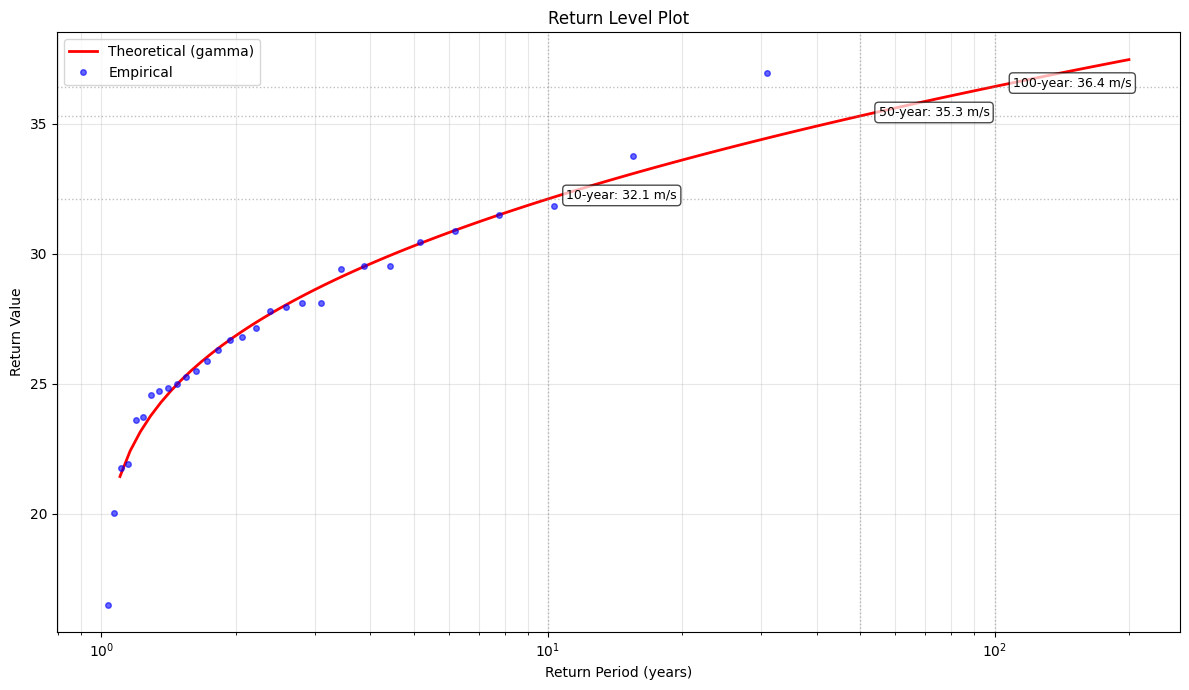


📊 Return Level Plot Interpretation:
   • Blue points: Empirical return levels from observed annual maxima
   • Red line: Theoretical return levels from fitted fitted block-maxima distribution
   • Good agreement indicates the fitted block-maxima model fits well
   • Deviations at high return periods are common due to extrapolation


In [7]:
# Create return level plot
fig, ax = plt.subplots(figsize=(12, 7))

maxima_extremes.plot_return_levels(
    ax=ax,
    return_periods=np.logspace(np.log10(1.1), np.log10(200), 100),  # From 1.1 to 200 years
)

# Add reference lines for common design return periods
design_periods = [10, 50, 100]
for T in design_periods:
    rv = maxima_extremes.return_value(T)
    ax.axhline(rv, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax.axvline(T, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax.text(T * 1.1, rv, f'{T}-year: {rv:.1f} m/s', fontsize=9, 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n📊 Return Level Plot Interpretation:")
print("   • Blue points: Empirical return levels from observed annual maxima")
print("   • Red line: Theoretical return levels from fitted fitted block-maxima distribution")
print("   • Good agreement indicates the fitted block-maxima model fits well")
print("   • Deviations at high return periods are common due to extrapolation")

## Peaks Over Threshold (POT) Approach: Generalized Pareto Distribution (GPD)

The POT method identifies all values exceeding a high threshold and fits a GPD to the exceedances. This approach uses more data than block maxima and can be more efficient.

In [8]:
# Choose threshold (e.g., 95th percentile)
threshold = np.percentile(wind_speeds, 95)
print(f"Threshold for POT analysis: {threshold:.2f} m/s (95th percentile)")

# Extract peaks over threshold with declustering
# Select the maximum in each 3-day window
peaks, peak_times = extremes.peaks_over_threshold(
    threshold=threshold,
    min_separation=3,  # Window duration in days
    peak_selection='max'
)

print(f"\nPeaks Over Threshold Analysis:")
print(f"Number of peaks identified: {len(peaks)}")
print(f"Average exceedance rate: {len(peaks) / extremes.time_span:.2f} peaks/year")
print(f"\nFirst 10 peaks:")
for i, (peak, time) in enumerate(zip(peaks[:10], peak_times[:10])):
    print(f"  {i+1}. {time}: {peak:.2f} m/s (exceedance: {peak - threshold:.2f} m/s)")

Threshold for POT analysis: 13.55 m/s (95th percentile)

Peaks Over Threshold Analysis:
Number of peaks identified: 340
Average exceedance rate: 11.33 peaks/year

First 10 peaks:
  1. 1990-01-02 00:00:00: 14.16 m/s (exceedance: 0.61 m/s)
  2. 1990-01-12 00:00:00: 14.91 m/s (exceedance: 1.36 m/s)
  3. 1990-02-04 00:00:00: 14.54 m/s (exceedance: 0.99 m/s)
  4. 1990-02-20 00:00:00: 14.26 m/s (exceedance: 0.71 m/s)
  5. 1990-03-11 00:00:00: 14.40 m/s (exceedance: 0.85 m/s)
  6. 1990-05-02 00:00:00: 28.12 m/s (exceedance: 14.56 m/s)
  7. 1990-06-09 00:00:00: 19.67 m/s (exceedance: 6.12 m/s)
  8. 1990-07-14 00:00:00: 18.17 m/s (exceedance: 4.62 m/s)
  9. 1990-07-17 00:00:00: 19.66 m/s (exceedance: 6.11 m/s)
  10. 1990-08-27 00:00:00: 18.29 m/s (exceedance: 4.74 m/s)


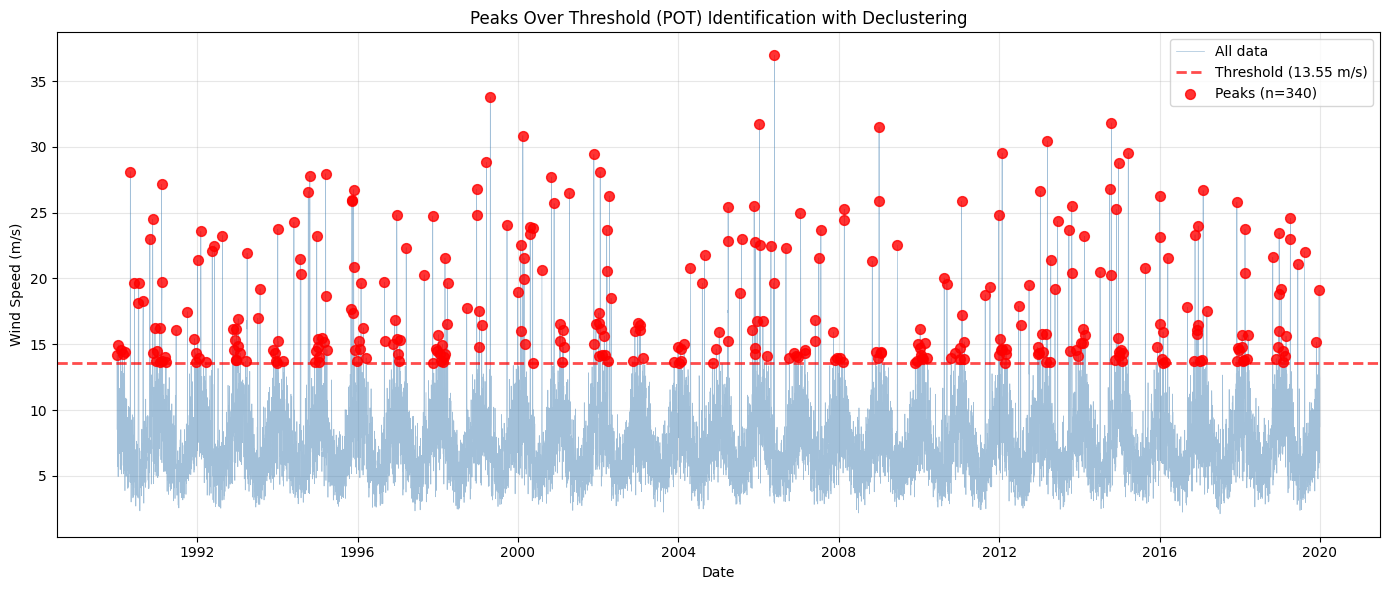


💡 Declustering selects one maximum per 3-day window
   A long storm can span multiple windows; assess independence separately.


In [9]:
# Visualize the POT extraction
fig, ax = plt.subplots(figsize=(14, 6))

# Plot full time series
ax.plot(dates, wind_speeds, linewidth=0.5, alpha=0.5, color='steelblue', label='All data')

# Highlight threshold
ax.axhline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.2f} m/s)', alpha=0.7)

# Mark identified peaks
ax.scatter(peak_times, peaks, color='red', s=50, zorder=5, label=f'Peaks (n={len(peaks)})', alpha=0.8)

ax.set_xlabel('Date')
ax.set_ylabel('Wind Speed (m/s)')
ax.set_title('Peaks Over Threshold (POT) Identification with Declustering')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Declustering selects one maximum per {3}-day window")
print(f"   A long storm can span multiple windows; assess independence separately.")

In [10]:
# Fit GPD to exceedances (peaks - threshold)
exceedances = peaks - threshold

exceedance_processor = ma.read_data(exceedances)

# Create ExtremesAnalyzer for exceedances
# We specify time_unit='years' here because we'll need it for POT return value calculations
# (which depend on the exceedance rate per year from the original series)
pot_extremes = exceedance_processor.get_extremes_analyzer(time_unit='years')

# Fit GPD (genpareto in SciPy) directly on the extremes analyzer
pot_extremes.fit_distribution('genpareto')

# Get fitted parameters
gpd_params = pot_extremes.fitted_params
print(f"Fitted GPD Parameters (for exceedances):")
print(f"Shape (ξ): {gpd_params[0]:.4f}")
print(f"Location: {gpd_params[1]:.4f}")
print(f"Scale (σ): {gpd_params[2]:.4f}")

# Interpret the shape parameter
if gpd_params[0] > 0.1:
    print(f"\nInterpretation: Heavy-tailed distribution (higher probability of extremes)")
elif gpd_params[0] < -0.1:
    print(f"\nInterpretation: Short-tailed distribution (finite upper bound)")
else:
    print(f"\nInterpretation: Exponential-like tails")

Fitted GPD Parameters (for exceedances):
Shape (ξ): 0.1972
Location: 0.0022
Scale (σ): 3.7078

Interpretation: Heavy-tailed distribution (higher probability of extremes)


/Users/danilocoutodesouza/Documents/Programs_and_scripts/MagicA/magica/core/extremes_analyzer.py:267: UserWarning: No time information provided. Assuming uniform time spacing. Return periods will be in units of observation count.
  warnings.warn(


## POT Return Value Calculation

For POT analysis, return values must account for the exceedance rate and threshold.

In [11]:
# Calculate POT-based return values
# Return value = threshold + GPD quantile adjusted for exceedance rate

exceedance_rate = len(peaks) / extremes.time_span  # peaks per year

print("Return Period Analysis (POT / GPD):")
print("=" * 60)
print(f"Exceedance rate: {exceedance_rate:.2f} peaks/year")
print(f"Threshold: {threshold:.2f} m/s\n")
print(f"{'Return Period':<20} {'Return Value (m/s)':<20} {'Exceedance Level'}")
print("-" * 60)

for T in return_periods:
    # For POT, the return period relates to the probability of exceeding the threshold
    # P(X > x | X > u) = (1 - F_GPD(x-u))
    # Return level: x = u + scale * ((λT)^ξ - 1) / ξ, where λ is exceedance rate
    
    # Using the fitted GPD to calculate the quantile
    prob = 1.0 / (exceedance_rate * T)  # Probability in the GPD scale
    if prob < 1.0:
        exceedance_quantile = pot_extremes.ppf(1 - prob)
        rv_pot = threshold + exceedance_quantile
    else:
        rv_pot = np.nan
    
    if not np.isnan(rv_pot):
        exceedance = rv_pot - threshold
        print(f"{T} years{'':<13} {rv_pot:.2f}{'':<15} +{exceedance:.2f} m/s")
    else:
        print(f"{T} years{'':<13} {'N/A':<20} {'N/A'}")

print("\n💡 POT return values account for:")
print("   • The threshold level (base wind speed)")
print("   • The exceedance distribution (GPD)")
print("   • The rate of threshold exceedances")

Return Period Analysis (POT / GPD):
Exceedance rate: 11.33 peaks/year
Threshold: 13.55 m/s

Return Period        Return Value (m/s)   Exceedance Level
------------------------------------------------------------
2 years              29.55                +15.99 m/s
5 years              36.44                +22.88 m/s
10 years              42.54                +28.99 m/s
20 years              49.54                +35.99 m/s
50 years              60.39                +46.84 m/s
100 years              70.01                +56.46 m/s

💡 POT return values account for:
   • The threshold level (base wind speed)
   • The exceedance distribution (GPD)
   • The rate of threshold exceedances


## Comparing Block Maxima vs POT Approaches

Let's compare the return value estimates from both methods.

## Advanced Declustering: Event-Wise vs Time-Based Windows

Declustering reduces repeated exceedances, but statistical independence should be assessed separately. There are two main approaches:

1. **Time-based windows**: Start a window at the first ungrouped exceedance and select its maximum (`peak_selection='max'`, the default). The start is included and the end is excluded. Select `'first'` or `'last'` for the first or last observation instead.
2. **Event-wise declustering**: Identify consecutive periods above threshold as single events and extract the maximum from each event. This mode does not use `peak_selection`.

For daily observations, a 3-day window starting on January 14 includes January 14–16; January 17 can start the next window. The selected peaks can be less than 3 days apart. Maximum ties keep the first observation, and the returned dates always belong to the selected observations.

Only values **strictly above** the threshold are selected. With datetime input and no exceedances, all three methods return an empty array and an empty `DatetimeIndex`.

Let's compare these approaches and see how the choice changes selected dates and values.


### A Five-Day Pulse: Selected Values and Dates

Use a symmetric pulse of **11, 12, 13, 12, 11 m/s** with a fixed threshold of **10 m/s**. This example shows the original dates returned by pure POT, the three time-based choices, and event-wise declustering.


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import magica as ma

# Daily wind: zero except for the five-day pulse
pulse_series = pd.Series(0.0, index=pd.date_range('2024-01-01', '2024-01-31'))
pulse_series.loc['2024-01-14':'2024-01-18'] = [11., 12., 13., 12., 11.]
pulse_extremes = ma.read_data(pulse_series).get_extremes_analyzer()
pulse_methods = {
    'Pure POT': {},
    'Time-based (max)': {'min_separation': '3D'},
    'Time-based (first)': {'min_separation': '3D', 'peak_selection': 'first'},
    'Time-based (last)': {'min_separation': '3D', 'peak_selection': 'last'},
    'Event-wise': {'event_wise': True},
}
pulse_results = {}
for label, options in pulse_methods.items():
    values, times = pulse_extremes.peaks_over_threshold(threshold=10, **options)
    pulse_results[label] = (values, times)
    print(f'{label}:')
    print(f'  Values (m/s): {values.tolist()}')
    print(f"  Dates: {times.strftime('%Y-%m-%d').tolist()}")

# max: [13.0, 12.0] on January 16 and 17, in different windows
# event-wise: [13.0] on January 16, one peak for the entire event
empty_values, empty_times = pulse_extremes.peaks_over_threshold(13, min_separation='3D')
print(f'No values above 13: {empty_values.tolist()}, {empty_times.tolist()}')
assert empty_values.size == len(empty_times) == 0


Pure POT:
  Values (m/s): [11.0, 12.0, 13.0, 12.0, 11.0]
  Dates: ['2024-01-14', '2024-01-15', '2024-01-16', '2024-01-17', '2024-01-18']
Time-based (max):
  Values (m/s): [13.0, 12.0]
  Dates: ['2024-01-16', '2024-01-17']
Time-based (first):
  Values (m/s): [11.0, 12.0]
  Dates: ['2024-01-14', '2024-01-17']
Time-based (last):
  Values (m/s): [13.0, 11.0]
  Dates: ['2024-01-16', '2024-01-18']
Event-wise:
  Values (m/s): [13.0]
  Dates: ['2024-01-16']
No values above 13: [], []


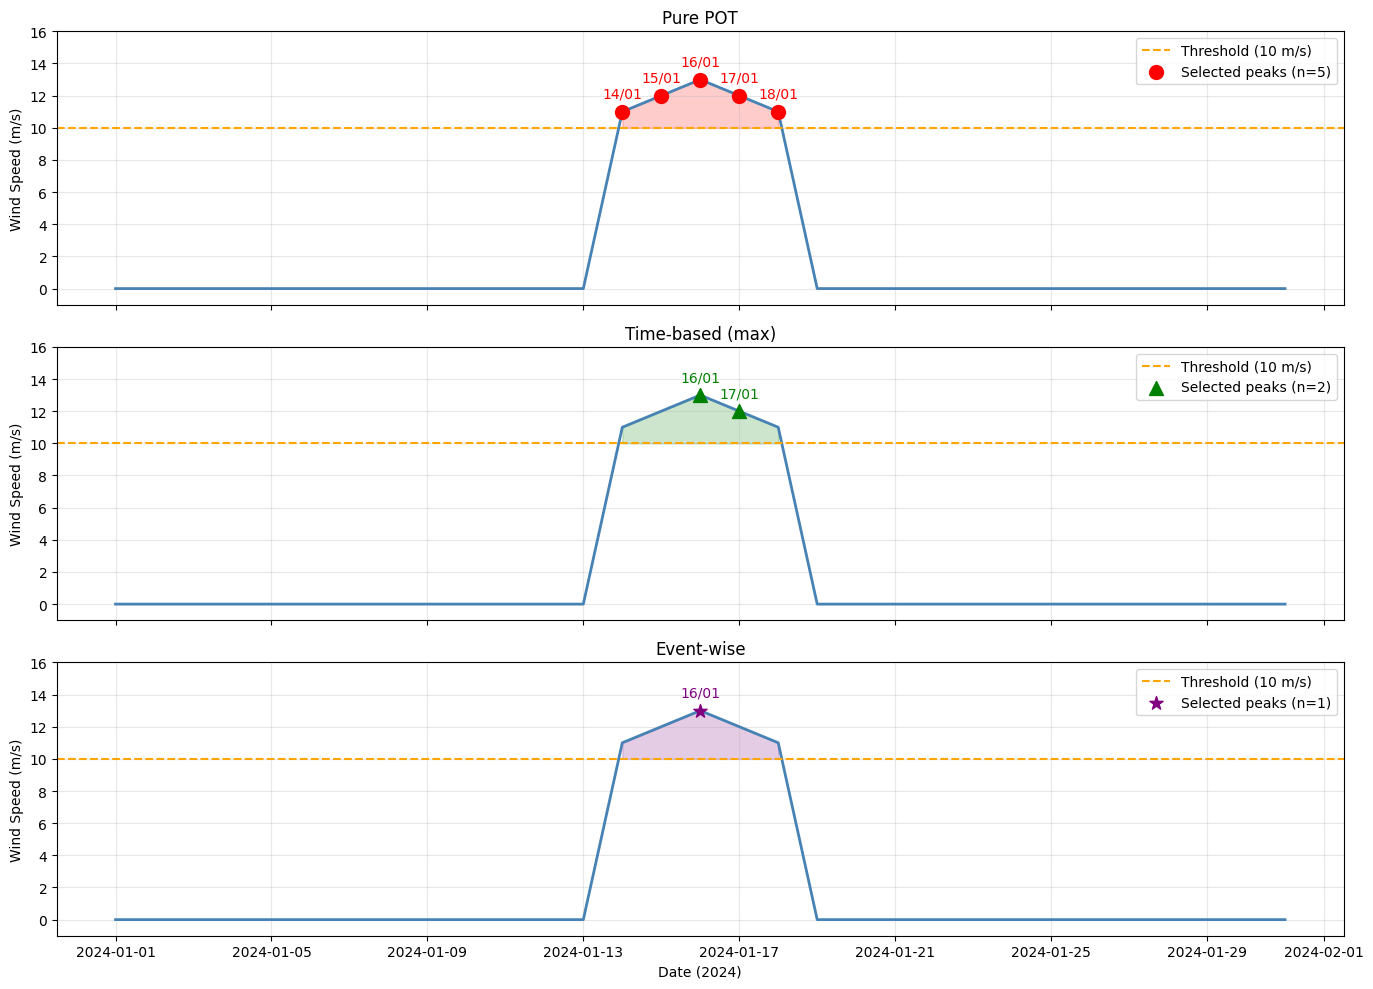

In [13]:
# Compare pure POT, time-window maxima, and event-wise maxima
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, sharey=True)
for ax, label, color, marker in zip(
    axes, ['Pure POT', 'Time-based (max)', 'Event-wise'],
    ['red', 'green', 'purple'], ['o', '^', '*']
):
    values, times = pulse_results[label]
    ax.plot(pulse_series.index, pulse_series.values, color='steelblue', linewidth=2)
    ax.axhline(10, color='orange', linestyle='--', label='Threshold (10 m/s)')
    ax.fill_between(pulse_series.index, 10, pulse_series.values,
                    where=pulse_series.values > 10, color=color, alpha=0.2)
    ax.scatter(times, values, color=color, marker=marker, s=100, zorder=5,
               label=f'Selected peaks (n={len(values)})')
    for time, value in zip(times, values):
        ax.annotate(time.strftime('%d/%m'), (time, value), xytext=(0, 10),
                    textcoords='offset points', ha='center', color=color)
    ax.set_title(label)
    ax.set_ylabel('Wind Speed (m/s)')
    ax.set_ylim(-1, 16)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
axes[-1].set_xlabel('Date (2024)')
plt.tight_layout()
plt.show()


In [14]:
# Compare different declustering methods at 90th percentile
threshold_90 = np.percentile(wind_speeds, 90)

# Method 1: No declustering (all exceedances)
peaks_all, times_all = extremes.peaks_over_threshold(threshold=threshold_90)

# Method 2: Time-based windows (3 days)
peaks_3days, times_3days = extremes.peaks_over_threshold(
    threshold=threshold_90, 
    min_separation=3,
    peak_selection='max'
)

# Method 3: Event-wise (consecutive days as single event)
peaks_eventwise, times_eventwise = extremes.peaks_over_threshold(
    threshold=threshold_90, 
    event_wise=True
)

print("Declustering Method Comparison (90th percentile threshold)")
print("=" * 70)
print(f"Threshold: {threshold_90:.2f} m/s")
print(f"\n{'Method':<25} {'# Peaks':<12} {'Mean Peak':<12} {'Max Peak'}")
print("-" * 70)
print(f"{'All exceedances':<25} {len(peaks_all):<12} {np.mean(peaks_all):<12.2f} {np.max(peaks_all):.2f}")
print(f"{'3-day windows':<25} {len(peaks_3days):<12} {np.mean(peaks_3days):<12.2f} {np.max(peaks_3days):.2f}")
print(f"{'Event-wise':<25} {len(peaks_eventwise):<12} {np.mean(peaks_eventwise):<12.2f} {np.max(peaks_eventwise):.2f}")

print(f"\n💡 Event-wise declustering identified {len(peaks_eventwise)} consecutive exceedance events")
print(f"   compared to {len(peaks_3days)} peaks with 3-day windows")
print(f"   and {len(peaks_all)} total exceedances.")

Declustering Method Comparison (90th percentile threshold)
Threshold: 11.78 m/s

Method                    # Peaks      Mean Peak    Max Peak
----------------------------------------------------------------------
All exceedances           1096         15.26        36.96
3-day windows             697          15.39        36.96
Event-wise                700          14.96        36.96

💡 Event-wise declustering identified 700 consecutive exceedance events
   compared to 697 peaks with 3-day windows
   and 1096 total exceedances.


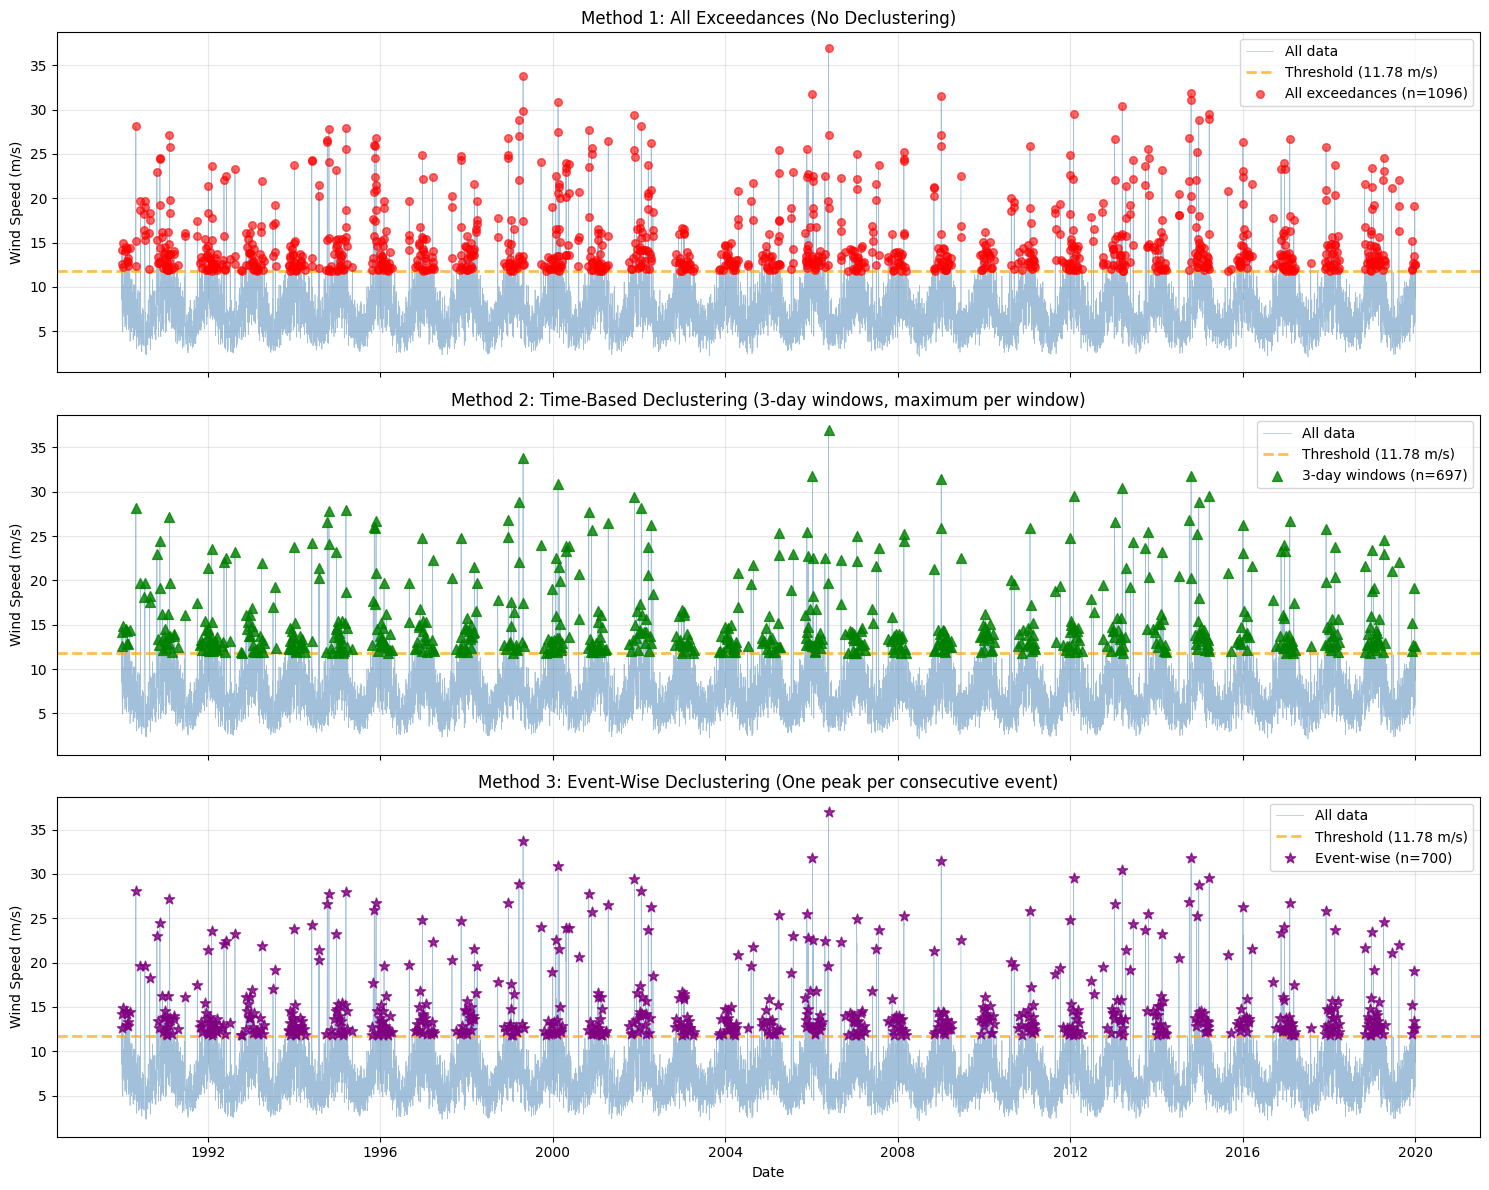


📊 Interpretation:
   • Top: Shows all days exceeding threshold (may include multiple days from same storm)
   • Middle: Selects the maximum in each 3-day window (not a minimum gap between peaks)
   • Bottom: One peak per storm event (consecutive days grouped together)


In [15]:
# Visualize the difference between declustering methods
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Plot 1: All exceedances
ax = axes[0]
ax.plot(dates, wind_speeds, linewidth=0.5, alpha=0.5, color='steelblue', label='All data')
ax.axhline(threshold_90, color='orange', linestyle='--', linewidth=2, 
           label=f'Threshold ({threshold_90:.2f} m/s)', alpha=0.7)
ax.scatter(times_all, peaks_all, color='red', s=30, zorder=5, 
          label=f'All exceedances (n={len(peaks_all)})', alpha=0.6)
ax.set_ylabel('Wind Speed (m/s)')
ax.set_title('Method 1: All Exceedances (No Declustering)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Plot 2: 3-day windows
ax = axes[1]
ax.plot(dates, wind_speeds, linewidth=0.5, alpha=0.5, color='steelblue', label='All data')
ax.axhline(threshold_90, color='orange', linestyle='--', linewidth=2, 
           label=f'Threshold ({threshold_90:.2f} m/s)', alpha=0.7)
ax.scatter(times_3days, peaks_3days, color='green', s=50, zorder=5, 
          label=f'3-day windows (n={len(peaks_3days)})', alpha=0.8, marker='^')
ax.set_ylabel('Wind Speed (m/s)')
ax.set_title('Method 2: Time-Based Declustering (3-day windows, maximum per window)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Plot 3: Event-wise
ax = axes[2]
ax.plot(dates, wind_speeds, linewidth=0.5, alpha=0.5, color='steelblue', label='All data')
ax.axhline(threshold_90, color='orange', linestyle='--', linewidth=2, 
           label=f'Threshold ({threshold_90:.2f} m/s)', alpha=0.7)
ax.scatter(times_eventwise, peaks_eventwise, color='purple', s=60, zorder=5, 
          label=f'Event-wise (n={len(peaks_eventwise)})', alpha=0.8, marker='*')
ax.set_xlabel('Date')
ax.set_ylabel('Wind Speed (m/s)')
ax.set_title('Method 3: Event-Wise Declustering (One peak per consecutive event)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("   • Top: Shows all days exceeding threshold (may include multiple days from same storm)")
print("   • Middle: Selects the maximum in each 3-day window (not a minimum gap between peaks)")
print("   • Bottom: One peak per storm event (consecutive days grouped together)")

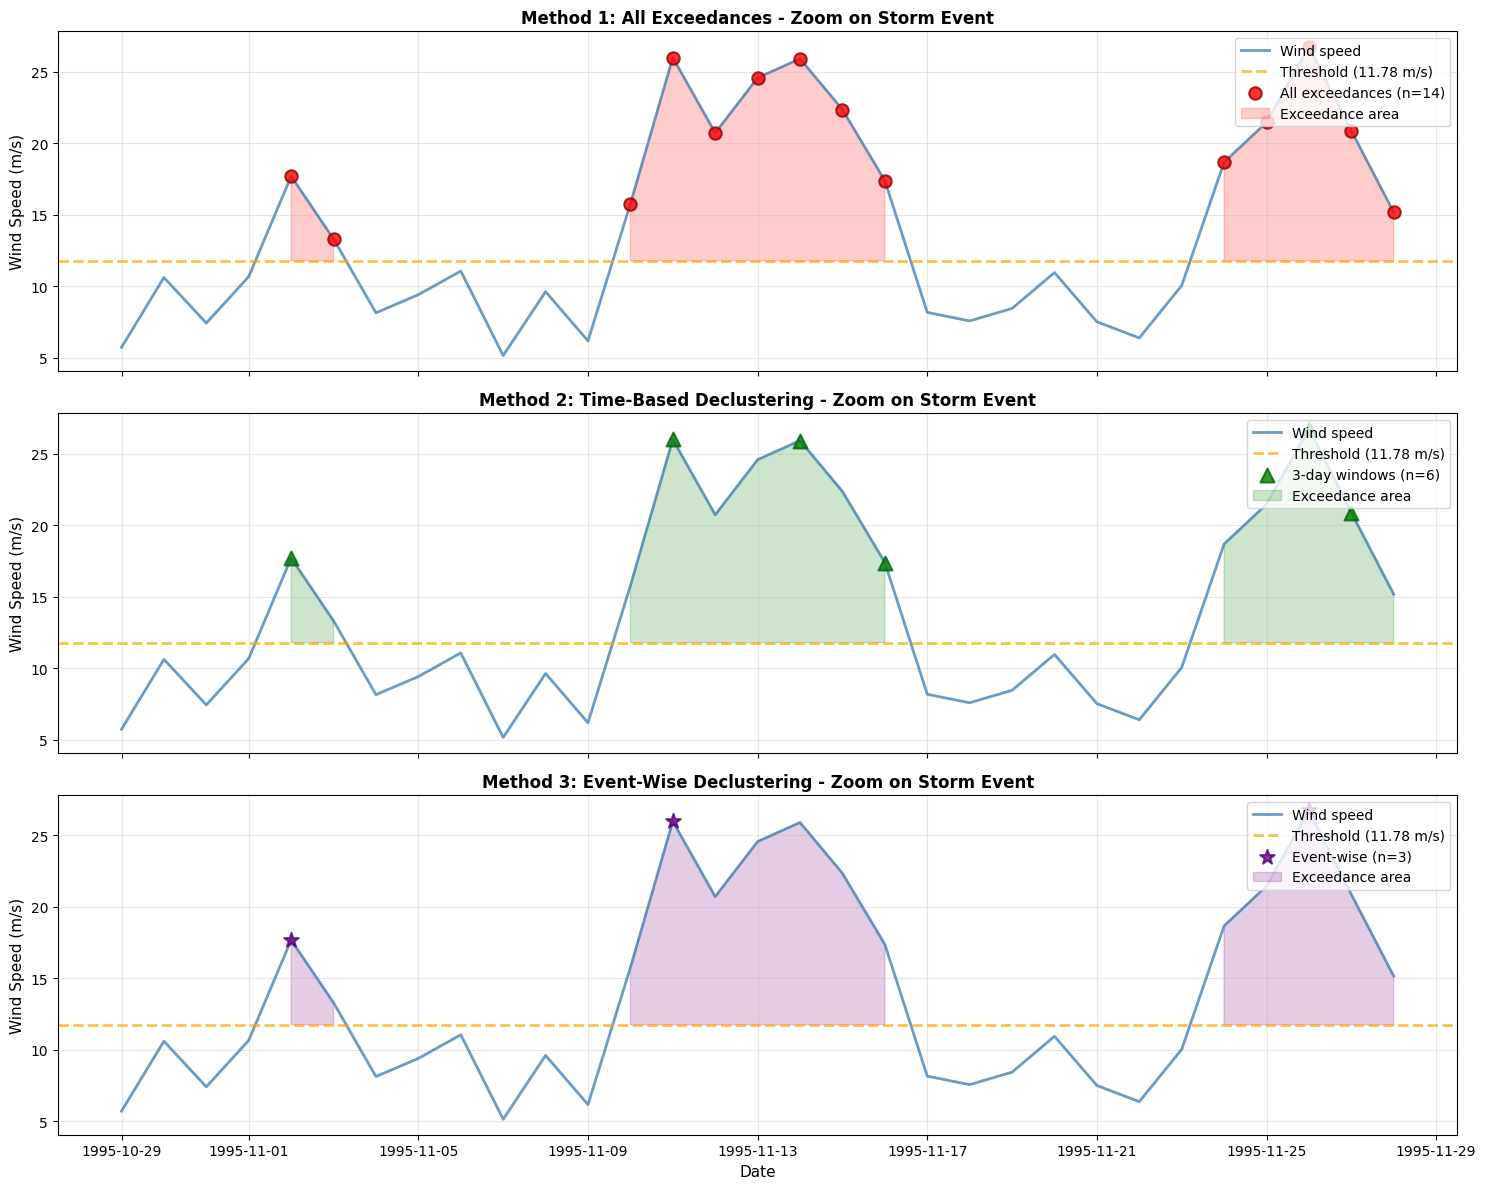


🔍 Detailed Storm Analysis:
Period shown: 1995-10-29 to 1995-11-28 (~1 month)
Storm duration: 7 consecutive days above threshold

Peaks identified in this window:
  • All exceedances: 14 peaks
  • 3-day windows: 6 peaks
  • Event-wise: 3 peak(s)

💡 Notice how:
   - All exceedances captures every day above threshold (may count same storm multiple times)
   - 3-day windows reduces but may still capture multiple peaks from one extended storm
   - Event-wise correctly identifies this as a single storm event with one representative peak


In [16]:
# Zoom in on a specific storm event to illustrate the differences
# Find a period with multiple consecutive exceedances
exceedance_mask = wind_speeds > threshold_90
consecutive_periods = []
in_period = False
period_start = None

for i, (date, exceeds) in enumerate(zip(dates, exceedance_mask)):
    if exceeds and not in_period:
        # Start of a new period
        period_start = i
        in_period = True
    elif not exceeds and in_period:
        # End of period
        consecutive_periods.append((period_start, i - 1))
        in_period = False

# If still in a period at the end
if in_period:
    consecutive_periods.append((period_start, len(dates) - 1))

# Find the longest consecutive period (most interesting storm)
longest_period = max(consecutive_periods, key=lambda x: x[1] - x[0])
storm_center = (longest_period[0] + longest_period[1]) // 2

# Extract 1 month window around this storm (±15 days)
window_days = 15
zoom_start = max(0, storm_center - window_days)
zoom_end = min(len(dates) - 1, storm_center + window_days)

zoom_dates = dates[zoom_start:zoom_end+1]
zoom_winds = wind_speeds[zoom_start:zoom_end+1]

# Filter peaks to this window
mask_all = (times_all >= zoom_dates[0]) & (times_all <= zoom_dates[-1])
mask_3days = (times_3days >= zoom_dates[0]) & (times_3days <= zoom_dates[-1])
mask_eventwise = (times_eventwise >= zoom_dates[0]) & (times_eventwise <= zoom_dates[-1])

zoom_peaks_all = peaks_all[mask_all]
zoom_times_all = times_all[mask_all]
zoom_peaks_3days = peaks_3days[mask_3days]
zoom_times_3days = times_3days[mask_3days]
zoom_peaks_eventwise = peaks_eventwise[mask_eventwise]
zoom_times_eventwise = times_eventwise[mask_eventwise]

# Create detailed zoom plot
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Plot 1: All exceedances
ax = axes[0]
ax.plot(zoom_dates, zoom_winds, linewidth=2, color='steelblue', label='Wind speed', alpha=0.8)
ax.axhline(threshold_90, color='orange', linestyle='--', linewidth=2, 
           label=f'Threshold ({threshold_90:.2f} m/s)', alpha=0.7)
ax.scatter(zoom_times_all, zoom_peaks_all, color='red', s=80, zorder=5, 
          label=f'All exceedances (n={len(zoom_peaks_all)})', alpha=0.8, edgecolors='darkred', linewidth=1.5)
ax.fill_between(zoom_dates, threshold_90, zoom_winds, 
                where=(zoom_winds > threshold_90), alpha=0.2, color='red', label='Exceedance area')
ax.set_ylabel('Wind Speed (m/s)', fontsize=11)
ax.set_title('Method 1: All Exceedances - Zoom on Storm Event', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: 3-day windows
ax = axes[1]
ax.plot(zoom_dates, zoom_winds, linewidth=2, color='steelblue', label='Wind speed', alpha=0.8)
ax.axhline(threshold_90, color='orange', linestyle='--', linewidth=2, 
           label=f'Threshold ({threshold_90:.2f} m/s)', alpha=0.7)
ax.scatter(zoom_times_3days, zoom_peaks_3days, color='green', s=100, zorder=5, 
          label=f'3-day windows (n={len(zoom_peaks_3days)})', alpha=0.8, marker='^', 
          edgecolors='darkgreen', linewidth=1.5)
ax.fill_between(zoom_dates, threshold_90, zoom_winds, 
                where=(zoom_winds > threshold_90), alpha=0.2, color='green', label='Exceedance area')
ax.set_ylabel('Wind Speed (m/s)', fontsize=11)
ax.set_title('Method 2: Time-Based Declustering - Zoom on Storm Event', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 3: Event-wise
ax = axes[2]
ax.plot(zoom_dates, zoom_winds, linewidth=2, color='steelblue', label='Wind speed', alpha=0.8)
ax.axhline(threshold_90, color='orange', linestyle='--', linewidth=2, 
           label=f'Threshold ({threshold_90:.2f} m/s)', alpha=0.7)
ax.scatter(zoom_times_eventwise, zoom_peaks_eventwise, color='purple', s=120, zorder=5, 
          label=f'Event-wise (n={len(zoom_peaks_eventwise)})', alpha=0.8, marker='*', 
          edgecolors='indigo', linewidth=1.5)
ax.fill_between(zoom_dates, threshold_90, zoom_winds, 
                where=(zoom_winds > threshold_90), alpha=0.2, color='purple', label='Exceedance area')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Wind Speed (m/s)', fontsize=11)
ax.set_title('Method 3: Event-Wise Declustering - Zoom on Storm Event', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Format x-axis
for ax in axes:
    ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

print(f"\n🔍 Detailed Storm Analysis:")
print(f"Period shown: {zoom_dates[0].date()} to {zoom_dates[-1].date()} (~1 month)")
print(f"Storm duration: {longest_period[1] - longest_period[0] + 1} consecutive days above threshold")
print(f"\nPeaks identified in this window:")
print(f"  • All exceedances: {len(zoom_peaks_all)} peaks")
print(f"  • 3-day windows: {len(zoom_peaks_3days)} peaks")
print(f"  • Event-wise: {len(zoom_peaks_eventwise)} peak(s)")
print(f"\n💡 Notice how:")
print(f"   - All exceedances captures every day above threshold (may count same storm multiple times)")
print(f"   - 3-day windows reduces but may still capture multiple peaks from one extended storm")
print(f"   - Event-wise correctly identifies this as a single storm event with one representative peak")

### Impact of Threshold Selection on Event Identification

Different thresholds will identify different numbers of events with varying characteristics. Let's explore how threshold choice affects the storm identification.

In [17]:
# Test different thresholds with event-wise declustering
percentiles = [85, 90, 95, 98]
threshold_results = {}

for p in percentiles:
    thresh = np.percentile(wind_speeds, p)
    peaks_evt, times_evt = extremes.peaks_over_threshold(
        threshold=thresh,
        event_wise=True
    )
    
    # Calculate event statistics
    event_durations = []
    series = pd.Series(wind_speeds, index=dates)
    
    for event_time in times_evt:
        # Find the consecutive period around this peak
        event_mask = series > thresh
        # Find the continuous block containing this event
        idx_loc = series.index.get_loc(event_time)
        
        # Expand left
        start_idx = idx_loc
        while start_idx > 0 and event_mask.iloc[start_idx - 1]:
            start_idx -= 1
        
        # Expand right
        end_idx = idx_loc
        while end_idx < len(series) - 1 and event_mask.iloc[end_idx + 1]:
            end_idx += 1
        
        duration = end_idx - start_idx + 1
        event_durations.append(duration)
    
    threshold_results[p] = {
        'threshold': thresh,
        'n_events': len(peaks_evt),
        'mean_peak': np.mean(peaks_evt),
        'max_peak': np.max(peaks_evt),
        'mean_duration': np.mean(event_durations) if event_durations else 0,
        'max_duration': np.max(event_durations) if event_durations else 0,
        'peaks': peaks_evt,
        'times': times_evt
    }

# Display results
print("Impact of Threshold on Event Characteristics (Event-Wise Declustering)")
print("=" * 90)
print(f"{'Percentile':<12} {'Threshold':<12} {'# Events':<12} {'Mean Peak':<12} {'Mean Duration':<15} {'Max Duration'}")
print("-" * 90)

for p in percentiles:
    res = threshold_results[p]
    print(f"{p}th{'':<9} {res['threshold']:<12.2f} {res['n_events']:<12} "
          f"{res['mean_peak']:<12.2f} {res['mean_duration']:<15.1f} {res['max_duration']} days")

print("\n💡 Key Observations:")
print("   • Higher thresholds → Fewer but more intense events")
print("   • Lower thresholds → More events, including weaker/shorter storms")
print("   • Event duration shows how long storms persist above threshold")

Impact of Threshold on Event Characteristics (Event-Wise Declustering)
Percentile   Threshold    # Events     Mean Peak    Mean Duration   Max Duration
------------------------------------------------------------------------------------------
85th          10.76        1018         13.78        1.6             8 days
90th          11.78        700          14.96        1.6             7 days
95th          13.55        321          17.86        1.7             7 days
98th          17.57        116          23.53        1.9             5 days

💡 Key Observations:
   • Higher thresholds → Fewer but more intense events
   • Lower thresholds → More events, including weaker/shorter storms
   • Event duration shows how long storms persist above threshold



📊 Interpretation:
   Left: Trade-off between event frequency and intensity
   Right: Higher thresholds capture only the most persistent events


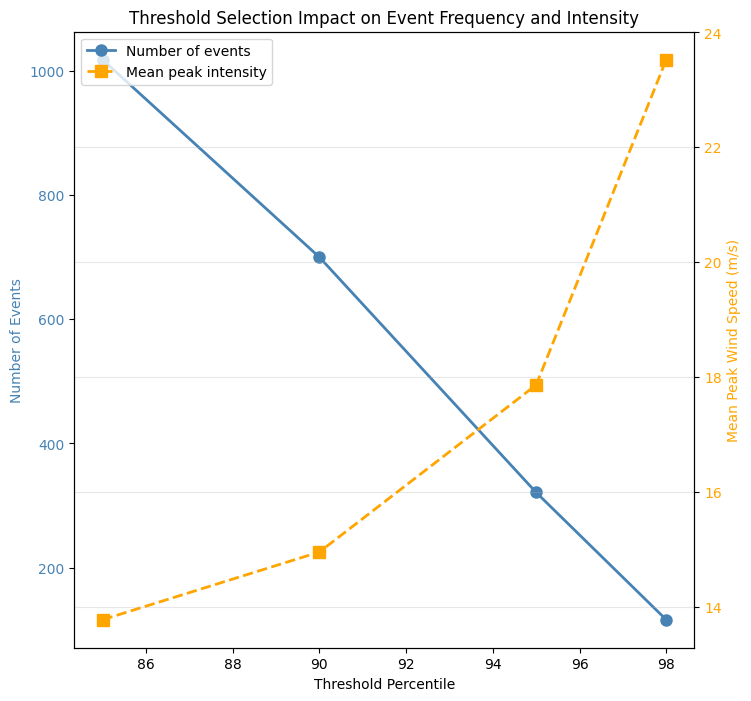

In [18]:
# Visualize threshold impact
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Plot: Number of events vs threshold
thresholds = [threshold_results[p]['threshold'] for p in percentiles]
n_events = [threshold_results[p]['n_events'] for p in percentiles]
mean_peaks = [threshold_results[p]['mean_peak'] for p in percentiles]

ax_twin = ax.twinx()
line1 = ax.plot(percentiles, n_events, 'o-', color='steelblue', linewidth=2, 
                 markersize=8, label='Number of events')
line2 = ax_twin.plot(percentiles, mean_peaks, 's--', color='orange', linewidth=2, 
                      markersize=8, label='Mean peak intensity')

ax.set_xlabel('Threshold Percentile')
ax.set_ylabel('Number of Events', color='steelblue')
ax_twin.set_ylabel('Mean Peak Wind Speed (m/s)', color='orange')
ax.set_title('Threshold Selection Impact on Event Frequency and Intensity')
ax.tick_params(axis='y', labelcolor='steelblue')
ax_twin.tick_params(axis='y', labelcolor='orange')
ax_twin.grid(True, alpha=0.3)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='upper left')

print("\n📊 Interpretation:")
print("   Left: Trade-off between event frequency and intensity")
print("   Right: Higher thresholds capture only the most persistent events")

### Comparing GPD Fits: Event-Wise vs Time-Based Declustering

Let's see how the choice of declustering method affects the fitted GPD distribution and return value estimates.

In [19]:
# Compare GPD fits with different declustering methods
threshold_compare = threshold_90

# Get peaks with both methods
peaks_time, times_time = extremes.peaks_over_threshold(threshold=threshold_compare, min_separation=3, peak_selection='max')
peaks_event, times_event = extremes.peaks_over_threshold(threshold=threshold_compare, event_wise=True)

# Fit GPD to exceedances from both methods
exceedances_time = peaks_time - threshold_compare
exceedances_event = peaks_event - threshold_compare

# Time-based declustering
proc_time = ma.read_data(exceedances_time)
pot_time = proc_time.get_extremes_analyzer(time_unit='years')
pot_time.fit_distribution('genpareto')

# Event-wise declustering
proc_event = ma.read_data(exceedances_event)
pot_event = proc_event.get_extremes_analyzer(time_unit='years')
pot_event.fit_distribution('genpareto')

# Compare parameters
print("GPD Parameter Comparison")
print("=" * 70)
print(f"Threshold: {threshold_compare:.2f} m/s (90th percentile)")
print(f"\n{'Method':<25} {'# Peaks':<12} {'Shape (ξ)':<12} {'Scale (σ)'}")
print("-" * 70)

params_time = pot_time.fitted_params
params_event = pot_event.fitted_params

print(f"{'3-day windows':<25} {len(peaks_time):<12} {params_time[0]:<12.4f} {params_time[2]:.4f}")
print(f"{'Event-wise':<25} {len(peaks_event):<12} {params_event[0]:<12.4f} {params_event[2]:.4f}")

# Calculate return values
print("\n\nReturn Value Comparison (m/s)")
print("=" * 70)
print(f"{'Return Period':<20} {'3-day windows':<20} {'Event-wise':<20} {'Difference'}")
print("-" * 70)

rate_time = len(peaks_time) / extremes.time_span
rate_event = len(peaks_event) / extremes.time_span

for T in [10, 50, 100]:
    # Time-based
    prob_time = 1.0 / (rate_time * T)
    if prob_time < 1.0:
        rv_time = threshold_compare + pot_time.ppf(1 - prob_time)
    else:
        rv_time = np.nan
    
    # Event-wise
    prob_event = 1.0 / (rate_event * T)
    if prob_event < 1.0:
        rv_event = threshold_compare + pot_event.ppf(1 - prob_event)
    else:
        rv_event = np.nan
    
    if not np.isnan(rv_time) and not np.isnan(rv_event):
        diff = rv_event - rv_time
        print(f"{T} years{'':<13} {rv_time:<20.2f} {rv_event:<20.2f} {diff:+.2f}")

print("\n💡 Key Insights:")
print("   • Event-wise declustering reduces peak count (fewer selected peaks)")
print("   • This affects the exceedance rate and thus return value estimates")
print("   • Event-wise is more physically meaningful for clustered extremes (storms)")
print("   • Time-based windows is simpler but may over-count dependent events")

GPD Parameter Comparison
Threshold: 11.78 m/s (90th percentile)

Method                    # Peaks      Shape (ξ)    Scale (σ)
----------------------------------------------------------------------
3-day windows             697          0.3367       2.4923
Event-wise                700          0.4381       1.9109


Return Value Comparison (m/s)
Return Period        3-day windows        Event-wise           Difference
----------------------------------------------------------------------
10 years              50.73                54.97                +4.24
50 years              84.06                103.66               +19.60
100 years              105.01               137.81               +32.80

💡 Key Insights:
   • Event-wise declustering reduces peak count (fewer selected peaks)
   • This affects the exceedance rate and thus return value estimates
   • Event-wise is more physically meaningful for clustered extremes (storms)
   • Time-based windows is simpler but may over-count depe

/Users/danilocoutodesouza/Documents/Programs_and_scripts/MagicA/magica/core/extremes_analyzer.py:267: UserWarning: No time information provided. Assuming uniform time spacing. Return periods will be in units of observation count.
  warnings.warn(


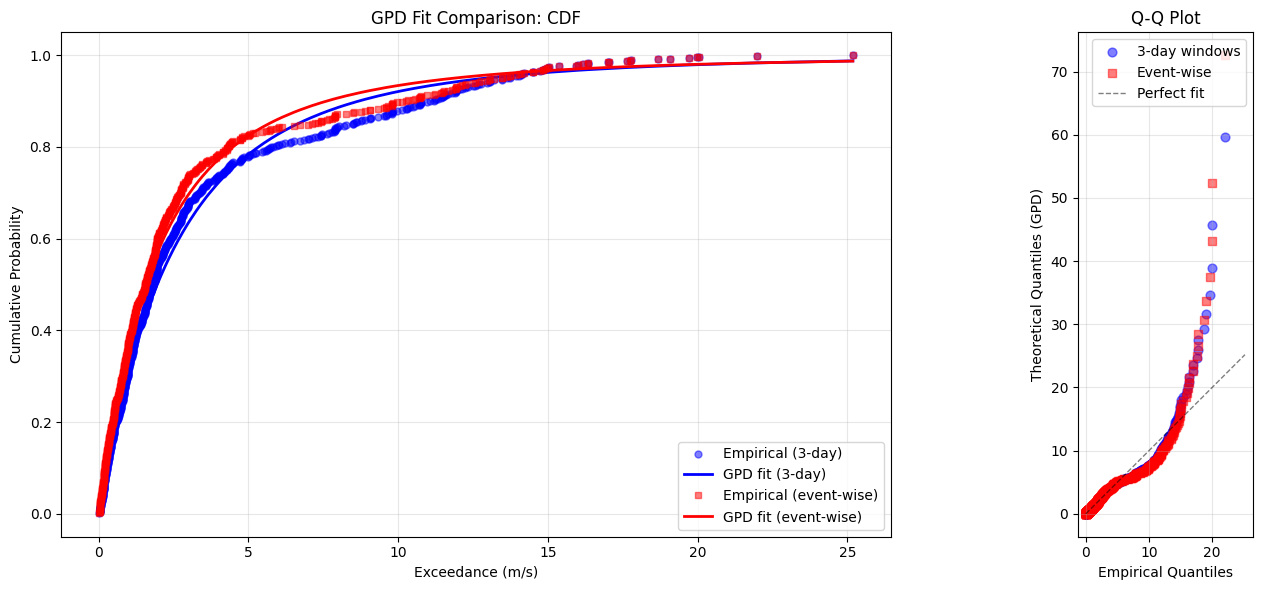


📊 Plot Interpretation:
   Left: Both methods show good GPD fits (empirical and theoretical CDFs align)
   Right: Q-Q plot shows how well data follows GPD (points near diagonal = good fit)


In [20]:
# Visualize the GPD fits
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Empirical vs fitted CDF
sorted_exc_time = np.sort(exceedances_time)
sorted_exc_event = np.sort(exceedances_event)

emp_cdf_time = np.arange(1, len(sorted_exc_time) + 1) / len(sorted_exc_time)
emp_cdf_event = np.arange(1, len(sorted_exc_event) + 1) / len(sorted_exc_event)

theo_cdf_time = pot_time.cdf(sorted_exc_time)
theo_cdf_event = pot_event.cdf(sorted_exc_event)

ax1.plot(sorted_exc_time, emp_cdf_time, 'o', color='blue', alpha=0.5, 
         markersize=5, label='Empirical (3-day)')
ax1.plot(sorted_exc_time, theo_cdf_time, '-', color='blue', linewidth=2, 
         label='GPD fit (3-day)')
ax1.plot(sorted_exc_event, emp_cdf_event, 's', color='red', alpha=0.5, 
         markersize=5, label='Empirical (event-wise)')
ax1.plot(sorted_exc_event, theo_cdf_event, '-', color='red', linewidth=2, 
         label='GPD fit (event-wise)')
ax1.set_xlabel('Exceedance (m/s)')
ax1.set_ylabel('Cumulative Probability')
ax1.set_title('GPD Fit Comparison: CDF')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Q-Q plot
ax2.scatter(sorted_exc_time, pot_time.ppf(emp_cdf_time), 
           color='blue', alpha=0.5, s=40, label='3-day windows')
ax2.scatter(sorted_exc_event, pot_event.ppf(emp_cdf_event), 
           color='red', alpha=0.5, s=40, label='Event-wise', marker='s')

# Add diagonal line
max_val = max(np.max(sorted_exc_time), np.max(sorted_exc_event))
ax2.plot([0, max_val], [0, max_val], 'k--', linewidth=1, alpha=0.5, label='Perfect fit')

ax2.set_xlabel('Empirical Quantiles')
ax2.set_ylabel('Theoretical Quantiles (GPD)')
ax2.set_title('Q-Q Plot')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

print("\n📊 Plot Interpretation:")
print("   Left: Both methods show good GPD fits (empirical and theoretical CDFs align)")
print("   Right: Q-Q plot shows how well data follows GPD (points near diagonal = good fit)")

In [21]:
# Calculate return values from both methods
comparison_periods = [5, 10, 20, 50, 100]

gev_values = [maxima_extremes.return_value(T) for T in comparison_periods]

# POT return values
pot_values = []
for T in comparison_periods:
    prob = 1.0 / (exceedance_rate * T)
    if prob < 1.0:
        exceedance_quantile = pot_extremes.ppf(1 - prob)
        pot_values.append(threshold + exceedance_quantile)
    else:
        pot_values.append(np.nan)

# Comparison table
print("Method Comparison: Block Maxima (GEV) vs POT (GPD)")
print("=" * 80)
print(f"{'Return Period':<15} {'GEV (m/s)':<15} {'GPD (m/s)':<15} {'Difference':<15} {'% Diff'}")
print("-" * 80)

for T, gev_val, pot_val in zip(comparison_periods, gev_values, pot_values):
    if not np.isnan(pot_val):
        diff = pot_val - gev_val
        pct_diff = (diff / gev_val) * 100
        print(f"{T} years{'':<8} {gev_val:<15.2f} {pot_val:<15.2f} {diff:<+15.2f} {pct_diff:+.1f}%")
    else:
        print(f"{T} years{'':<8} {gev_val:<15.2f} {'N/A':<15} {'N/A':<15} {'N/A'}")

print("\n📊 Method Selection Guidelines:")
print("\nBlock Maxima (GEV):")
print("  ✓ More robust, classical approach")
print("  ✓ Less sensitive to threshold selection")
print("  ✓ Better for data with clear seasonal structure")
print("  ✗ Uses less data (only one value per block)")
print("  ✗ Requires long time series for reliability")
print("\nPeaks Over Threshold (GPD):")
print("  ✓ More efficient, uses more extreme data")
print("  ✓ Better for short time series")
print("  ✓ Can adapt to changing extreme behavior")
print("  ✗ Sensitive to threshold choice")
print("  ✗ Requires careful declustering")
print("  ✗ More complex implementation")

Method Comparison: Block Maxima (GEV) vs POT (GPD)
Return Period   GEV (m/s)       GPD (m/s)       Difference      % Diff
--------------------------------------------------------------------------------
5 years         30.29           36.44           +6.14           +20.3%
10 years         32.10           42.54           +10.44          +32.5%
20 years         33.60           49.54           +15.94          +47.5%
50 years         35.29           60.39           +25.10          +71.1%
100 years         36.42           70.01           +33.59          +92.2%

📊 Method Selection Guidelines:

Block Maxima (GEV):
  ✓ More robust, classical approach
  ✓ Less sensitive to threshold selection
  ✓ Better for data with clear seasonal structure
  ✗ Uses less data (only one value per block)
  ✗ Requires long time series for reliability

Peaks Over Threshold (GPD):
  ✓ More efficient, uses more extreme data
  ✓ Better for short time series
  ✓ Can adapt to changing extreme behavior
  ✗ Sensitive to

## Visualizing Both Approaches Side-by-Side

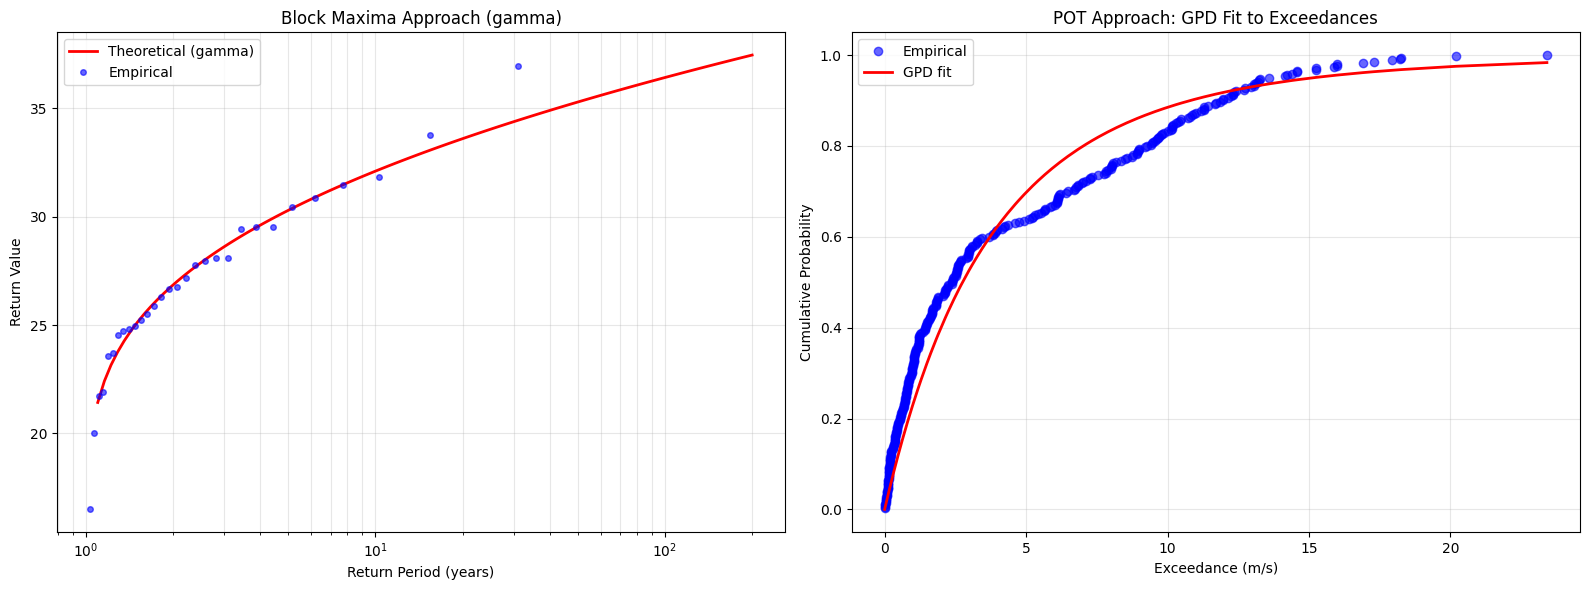

In [22]:
# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: fitted block-maxima return levels
maxima_extremes.plot_return_levels(
    ax=ax1,
    return_periods=np.logspace(np.log10(1.1), np.log10(200), 100),
    title=f'Block Maxima Approach ({best_dist_name})'
)

# Plot 2: Exceedance distribution (GPD)
sorted_exceedances = np.sort(exceedances)
empirical_cdf = np.arange(1, len(sorted_exceedances) + 1) / len(sorted_exceedances)
theoretical_cdf = pot_extremes.cdf(sorted_exceedances)

ax2.plot(sorted_exceedances, empirical_cdf, 'bo', markersize=6, alpha=0.6, label='Empirical')
ax2.plot(sorted_exceedances, theoretical_cdf, 'r-', linewidth=2, label='GPD fit')
ax2.set_xlabel('Exceedance (m/s)')
ax2.set_ylabel('Cumulative Probability')
ax2.set_title('POT Approach: GPD Fit to Exceedances')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Advanced: Monthly and Seasonal Block Maxima

Besides annual maxima, we can extract maxima from other time blocks.

In [23]:
# Extract monthly maxima
monthly_maxima = extremes.extract_block_maxima(block_size='ME', method='max')

print(f"Monthly Maxima Analysis:")
print(f"Number of months: {len(monthly_maxima[1])}")
print(f"Mean monthly maximum: {np.mean(list(monthly_maxima[0])):.2f} m/s")
print(f"\nFirst 12 months:")
for max_wind, month in zip(monthly_maxima[0][:12], monthly_maxima[1][:12]):
    print(f"{month.month}: {max_wind:.2f} m/s")

Monthly Maxima Analysis:
Number of months: 360
Mean monthly maximum: 15.32 m/s

First 12 months:
1: 14.91 m/s
2: 14.54 m/s
3: 14.40 m/s
4: 10.28 m/s
5: 28.12 m/s
6: 19.67 m/s
7: 19.66 m/s
8: 18.29 m/s
9: 10.83 m/s
10: 23.00 m/s
11: 24.49 m/s
12: 16.24 m/s


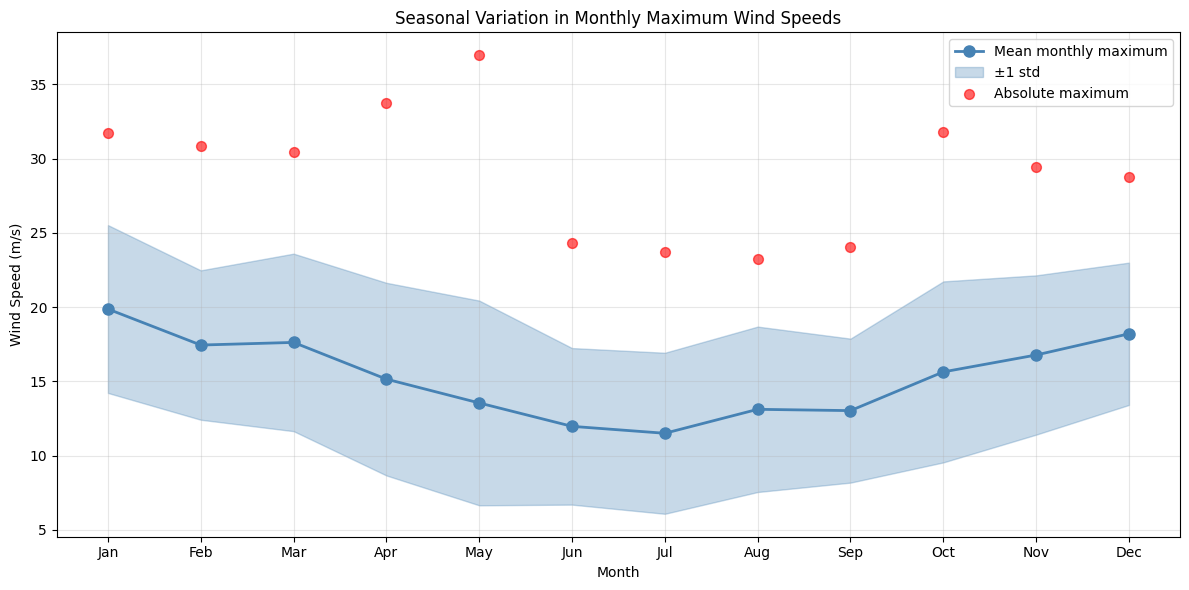


Most extreme month on average: Jan (19.87 m/s)
Least extreme month on average: Jul (11.50 m/s)


In [24]:
# Visualize seasonal variation in extremes
# Convert monthly maxima to DataFrame for easier analysis
# monthly_maxima is a tuple of (values, timestamps)
monthly_values, monthly_dates = monthly_maxima

monthly_df = pd.DataFrame({
    'date': monthly_dates,
    'max_wind': monthly_values
})
monthly_df['month'] = monthly_df['date'].dt.month
monthly_df['month_name'] = monthly_df['date'].dt.strftime('%b')

# Calculate monthly statistics
monthly_stats = monthly_df.groupby(['month', 'month_name'])['max_wind'].agg(['mean', 'std', 'min', 'max']).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

# Plot mean with error bars
months = monthly_stats['month'].values
means = monthly_stats['mean'].values
stds = monthly_stats['std'].values

ax.plot(months, means, 'o-', linewidth=2, markersize=8, color='steelblue', label='Mean monthly maximum')
ax.fill_between(months, means - stds, means + stds, alpha=0.3, color='steelblue', label='±1 std')
ax.scatter(months, monthly_stats['max'], color='red', s=50, zorder=5, alpha=0.6, label='Absolute maximum')

ax.set_xlabel('Month')
ax.set_ylabel('Wind Speed (m/s)')
ax.set_title('Seasonal Variation in Monthly Maximum Wind Speeds')
ax.set_xticks(months)
ax.set_xticklabels(monthly_stats['month_name'])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find the most extreme month
most_extreme_month = monthly_stats.loc[monthly_stats['mean'].idxmax()]
print(f"\nMost extreme month on average: {most_extreme_month['month_name']} ({most_extreme_month['mean']:.2f} m/s)")
print(f"Least extreme month on average: {monthly_stats.loc[monthly_stats['mean'].idxmin(), 'month_name']} "
      f"({monthly_stats['mean'].min():.2f} m/s)")

## Goodness-of-Fit Assessment for Extreme Value Distributions

Let's evaluate how well our distributions fit the extreme data using both statistical tests and visual diagnostics.

In [25]:
# Goodness-of-fit for fitted block-maxima (annual maxima)
print("Goodness-of-Fit Assessment:")
print("=" * 60)
print("\nBlock Maxima (fitted block-maxima):")

ks_gev = maxima_extremes.goodness_of_fit('ks')
print(f"  Kolmogorov-Smirnov Test:")
print(f"    Statistic: {ks_gev['ks_statistic']:.6f}")
print(f"    P-value: {ks_gev['p_value']:.6f}")
print(f"    Result: {'Good fit ✓' if ks_gev['p_value'] > 0.05 else 'Poor fit ✗'} (α = 0.05)")

rmse_gev = maxima_extremes.goodness_of_fit('rmse')
print(f"  RMSE: {rmse_gev:.6f}")

# Goodness-of-fit for GPD (exceedances)
print("\nPeaks Over Threshold (GPD):")

ks_gpd = pot_extremes.goodness_of_fit('ks')
print(f"  Kolmogorov-Smirnov Test:")
print(f"    Statistic: {ks_gpd['ks_statistic']:.6f}")
print(f"    P-value: {ks_gpd['p_value']:.6f}")
print(f"    Result: {'Good fit ✓' if ks_gpd['p_value'] > 0.05 else 'Poor fit ✗'} (α = 0.05)")

rmse_gpd = pot_extremes.goodness_of_fit('rmse')
print(f"  RMSE: {rmse_gpd:.6f}")

print("\n💡 Note: Small sample sizes in extreme value analysis often result in")
print("   lower statistical power. Visual inspection (see plots below) is equally important.")

Goodness-of-Fit Assessment:

Block Maxima (fitted block-maxima):
  Kolmogorov-Smirnov Test:
    Statistic: 0.086928
    P-value: 0.962403
    Result: Good fit ✓ (α = 0.05)
  RMSE: 0.032312

Peaks Over Threshold (GPD):
  Kolmogorov-Smirnov Test:
    Statistic: 0.107482
    P-value: 0.000711
    Result: Poor fit ✗ (α = 0.05)
  RMSE: 0.062456

💡 Note: Small sample sizes in extreme value analysis often result in
   lower statistical power. Visual inspection (see plots below) is equally important.


## Visual Goodness-of-Fit: Histograms and PDFs

Let's visualize how well the fitted distributions match the observed data by comparing histograms with the theoretical probability density functions (PDFs).

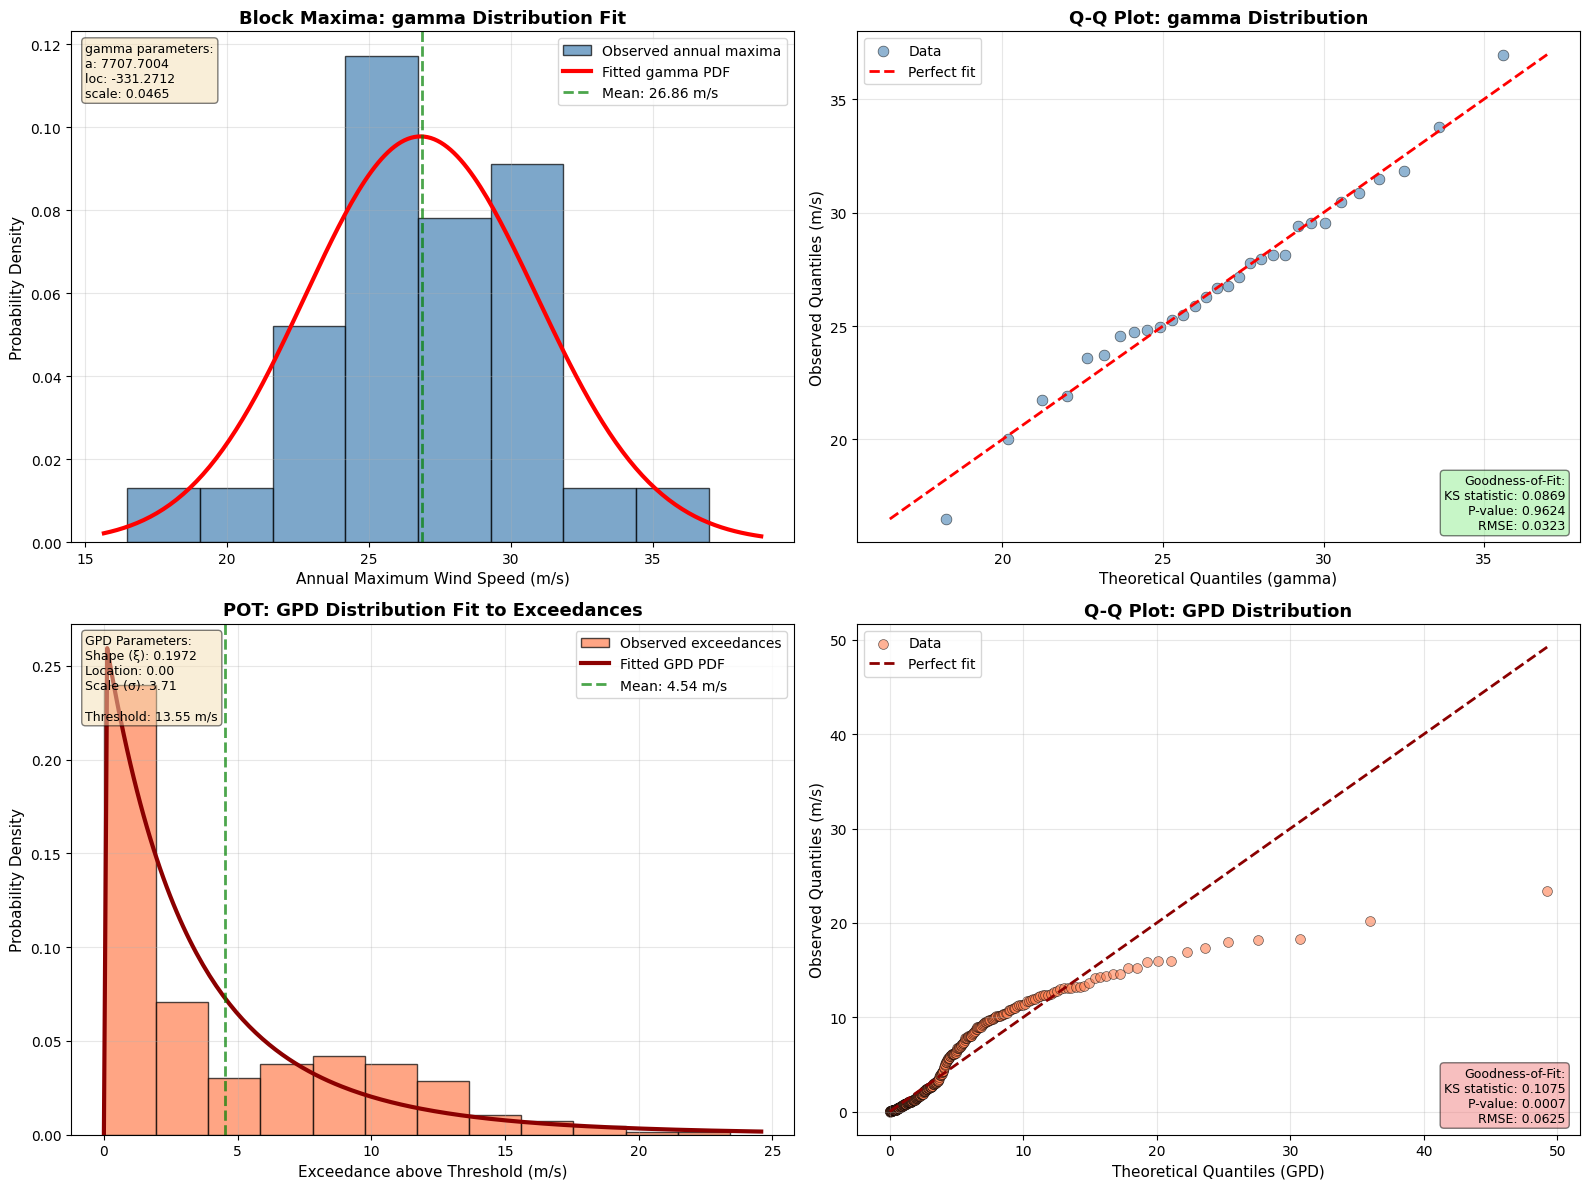


VISUAL GOODNESS-OF-FIT INTERPRETATION:

📊 LEFT COLUMN - Histogram vs PDF:
   • Blue/Coral bars: Observed frequency of extreme values
   • Red curves: Theoretical probability density from fitted distributions
   • Good fit: PDF curve should follow the histogram shape closely
   • Green dashed line: Mean of the observed data

📈 RIGHT COLUMN - Q-Q Plots (Quantile-Quantile):
   • Points: Comparison of observed vs theoretical quantiles
   • Red dashed line: Perfect fit (y = x)
   • Good fit: Points should lie close to the diagonal line
   • Deviations at extremes are common due to sampling variability

✅ fitted block-maxima (Top Row):
   • P-value: 0.9624 → GOOD FIT (α = 0.05)
   • RMSE: 0.032312 (lower is better)

✅ GPD (Bottom Row):
   • P-value: 0.0007 → POOR FIT (α = 0.05)
   • RMSE: 0.062456 (lower is better)

💡 Note: Visual inspection is crucial in extreme value analysis.
   Even with acceptable p-values, always check if the fit makes physical sense!


In [26]:
from scipy import stats

# Create comprehensive visualization of goodness-of-fit
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ============================================================================
# TOP ROW: Block Maxima (fitted block-maxima) Analysis
# ============================================================================

# Plot 1: Histogram + PDF for Annual Maxima (fitted block-maxima)
ax1 = axes[0, 0]
ax1.hist(maxima_values, bins=8, density=True, alpha=0.7, color='steelblue', 
         label='Observed annual maxima', edgecolor='black', linewidth=1)

# Generate smooth curve for fitted fitted block-maxima distribution
x_gev = np.linspace(min(maxima_values) * 0.95, max(maxima_values) * 1.05, 200)
pdf_gev = maxima_extremes.pdf(x_gev)
ax1.plot(x_gev, pdf_gev, 'r-', linewidth=3, label=f'Fitted {best_dist_name} PDF')

# Mark the mean
mean_maxima = np.mean(maxima_values)
ax1.axvline(mean_maxima, color='green', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_maxima:.2f} m/s', alpha=0.7)

ax1.set_xlabel('Annual Maximum Wind Speed (m/s)', fontsize=11)
ax1.set_ylabel('Probability Density', fontsize=11)
ax1.set_title(f'Block Maxima: {best_dist_name} Distribution Fit', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Add text box with fitted block-maxima parameters
param_text = f'{best_dist_name} parameters:\n' + '\n'.join(
    f'{name}: {value:.4f}'
    for name, value in zip((([name.strip() for name in getattr(stats, best_dist_name).shapes.split(',')] if getattr(stats, best_dist_name).shapes else []) + ['loc', 'scale']), params)
)
ax1.text(0.02, 0.98, param_text, transform=ax1.transAxes, fontsize=9,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Q-Q Plot for fitted block-maxima
ax2 = axes[0, 1]
sorted_maxima = np.sort(maxima_values)
n = len(sorted_maxima)
empirical_probs = (np.arange(1, n + 1) - 0.5) / n
theoretical_quantiles = maxima_extremes.ppf(empirical_probs)

ax2.scatter(theoretical_quantiles, sorted_maxima, alpha=0.6, s=60, color='steelblue', 
            edgecolor='black', linewidth=0.5, label='Data')
# Add perfect fit line
min_val = min(theoretical_quantiles.min(), sorted_maxima.min())
max_val = max(theoretical_quantiles.max(), sorted_maxima.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect fit')

ax2.set_xlabel(f'Theoretical Quantiles ({best_dist_name})', fontsize=11)
ax2.set_ylabel('Observed Quantiles (m/s)', fontsize=11)
ax2.set_title(f'Q-Q Plot: {best_dist_name} Distribution', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)

# Add goodness-of-fit statistics
gof_text = f'Goodness-of-Fit:\nKS statistic: {ks_gev["ks_statistic"]:.4f}\nP-value: {ks_gev["p_value"]:.4f}\nRMSE: {rmse_gev:.4f}'
ax2.text(0.98, 0.02, gof_text, transform=ax2.transAxes, fontsize=9,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightgreen' if ks_gev['p_value'] > 0.05 else 'lightcoral', alpha=0.5))

# ============================================================================
# BOTTOM ROW: POT (GPD) Analysis
# ============================================================================

# Plot 3: Histogram + PDF for Exceedances (GPD)
ax3 = axes[1, 0]
ax3.hist(exceedances, bins=12, density=True, alpha=0.7, color='coral', 
         label='Observed exceedances', edgecolor='black', linewidth=1)

# Generate smooth curve for fitted GPD distribution
x_gpd = np.linspace(0, max(exceedances) * 1.05, 200)
pdf_gpd = pot_extremes.pdf(x_gpd)
ax3.plot(x_gpd, pdf_gpd, 'darkred', linewidth=3, label='Fitted GPD PDF')

# Mark the mean
mean_exceedances = np.mean(exceedances)
ax3.axvline(mean_exceedances, color='green', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_exceedances:.2f} m/s', alpha=0.7)

ax3.set_xlabel('Exceedance above Threshold (m/s)', fontsize=11)
ax3.set_ylabel('Probability Density', fontsize=11)
ax3.set_title('POT: GPD Distribution Fit to Exceedances', fontsize=13, fontweight='bold')
ax3.legend(loc='upper right', fontsize=10)
ax3.grid(True, alpha=0.3)

# Add text box with GPD parameters
param_text_gpd = f'GPD Parameters:\nShape (ξ): {gpd_params[0]:.4f}\nLocation: {gpd_params[1]:.2f}\nScale (σ): {gpd_params[2]:.2f}\n\nThreshold: {threshold:.2f} m/s'
ax3.text(0.02, 0.98, param_text_gpd, transform=ax3.transAxes, fontsize=9,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 4: Q-Q Plot for GPD
ax4 = axes[1, 1]
sorted_exceedances = np.sort(exceedances)
n_exc = len(sorted_exceedances)
empirical_probs_exc = (np.arange(1, n_exc + 1) - 0.5) / n_exc
theoretical_quantiles_exc = pot_extremes.ppf(empirical_probs_exc)

ax4.scatter(theoretical_quantiles_exc, sorted_exceedances, alpha=0.6, s=50, color='coral', 
            edgecolor='black', linewidth=0.5, label='Data')
# Add perfect fit line
min_val_exc = min(theoretical_quantiles_exc.min(), sorted_exceedances.min())
max_val_exc = max(theoretical_quantiles_exc.max(), sorted_exceedances.max())
ax4.plot([min_val_exc, max_val_exc], [min_val_exc, max_val_exc], 'darkred', 
         linestyle='--', linewidth=2, label='Perfect fit')

ax4.set_xlabel('Theoretical Quantiles (GPD)', fontsize=11)
ax4.set_ylabel('Observed Quantiles (m/s)', fontsize=11)
ax4.set_title('Q-Q Plot: GPD Distribution', fontsize=13, fontweight='bold')
ax4.legend(loc='upper left', fontsize=10)
ax4.grid(True, alpha=0.3)

# Add goodness-of-fit statistics
gof_text_gpd = f'Goodness-of-Fit:\nKS statistic: {ks_gpd["ks_statistic"]:.4f}\nP-value: {ks_gpd["p_value"]:.4f}\nRMSE: {rmse_gpd:.4f}'
ax4.text(0.98, 0.02, gof_text_gpd, transform=ax4.transAxes, fontsize=9,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightgreen' if ks_gpd['p_value'] > 0.05 else 'lightcoral', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("VISUAL GOODNESS-OF-FIT INTERPRETATION:")
print("="*80)
print("\n📊 LEFT COLUMN - Histogram vs PDF:")
print("   • Blue/Coral bars: Observed frequency of extreme values")
print("   • Red curves: Theoretical probability density from fitted distributions")
print("   • Good fit: PDF curve should follow the histogram shape closely")
print("   • Green dashed line: Mean of the observed data")
print("\n📈 RIGHT COLUMN - Q-Q Plots (Quantile-Quantile):")
print("   • Points: Comparison of observed vs theoretical quantiles")
print("   • Red dashed line: Perfect fit (y = x)")
print("   • Good fit: Points should lie close to the diagonal line")
print("   • Deviations at extremes are common due to sampling variability")
print("\n✅ fitted block-maxima (Top Row):")
print(f"   • P-value: {ks_gev['p_value']:.4f} → {'GOOD FIT' if ks_gev['p_value'] > 0.05 else 'POOR FIT'} (α = 0.05)")
print(f"   • RMSE: {rmse_gev:.6f} (lower is better)")
print("\n✅ GPD (Bottom Row):")
print(f"   • P-value: {ks_gpd['p_value']:.4f} → {'GOOD FIT' if ks_gpd['p_value'] > 0.05 else 'POOR FIT'} (α = 0.05)")
print(f"   • RMSE: {rmse_gpd:.6f} (lower is better)")
print("\n💡 Note: Visual inspection is crucial in extreme value analysis.")
print("   Even with acceptable p-values, always check if the fit makes physical sense!")
print("="*80)

## Summary Statistics and Report

Let's generate a comprehensive summary of the extreme value analysis.

In [27]:
# Get summary statistics from ExtremesAnalyzer
summary = extremes.get_summary_statistics()

print("EXTREME VALUE ANALYSIS SUMMARY REPORT")
print("=" * 80)
print(f"\nDataset Information:")
print(f"  Period: {dates[0].date()} to {dates[-1].date()}")
print(f"  Duration: {extremes.time_span:.2f} years")
print(f"  Total observations: {summary['n_observations']}")
print(f"  Time unit: {summary['time_unit']}")

print(f"\nData Statistics:")
print(f"  Mean: {summary['mean']:.2f} m/s")
print(f"  Std Dev: {summary['std']:.2f} m/s")
print(f"  Minimum: {summary['min']:.2f} m/s")
print(f"  Maximum: {summary['max']:.2f} m/s")
print(f"  95th percentile: {summary['percentile_95']:.2f} m/s")
print(f"  99th percentile: {summary['percentile_99']:.2f} m/s")

if summary['distribution_name']:
    print(f"\nFitted Distribution: {summary['distribution_name']}")
    print(f"  Parameters: {summary['distribution_params']}")

print(f"\nBlock Maxima Analysis:")
print(f"  Annual maxima: {len(annual_maxima)} years")
print(f"  Mean annual maximum: {np.mean(maxima_values):.2f} m/s")
print(f"  GEV shape parameter: {params[0]:.4f}")

print(f"\nPOT Analysis:")
print(f"  Threshold: {threshold:.2f} m/s (95th percentile)")
print(f"  Number of peaks: {len(peaks)}")
print(f"  Exceedance rate: {exceedance_rate:.2f} peaks/year")
print(f"  GPD shape parameter: {gpd_params[0]:.4f}")

print(f"\nDesign Wind Speeds (GEV):")
for T in [10, 50, 100]:
    rv = maxima_extremes.return_value(T)
    print(f"  {T}-year return value: {rv:.2f} m/s")

print("\n" + "=" * 80)

EXTREME VALUE ANALYSIS SUMMARY REPORT

Dataset Information:
  Period: 1990-01-01 to 2019-12-31
  Duration: 30.00 years
  Total observations: 10957
  Time unit: years

Data Statistics:
  Mean: 7.82 m/s
  Std Dev: 3.48 m/s
  Minimum: 2.11 m/s
  Maximum: 36.96 m/s
  95th percentile: 13.55 m/s
  99th percentile: 22.09 m/s

Block Maxima Analysis:
  Annual maxima: 30 years
  Mean annual maximum: 26.86 m/s
  GEV shape parameter: 7707.7004

POT Analysis:
  Threshold: 13.55 m/s (95th percentile)
  Number of peaks: 340
  Exceedance rate: 11.33 peaks/year
  GPD shape parameter: 0.1972

Design Wind Speeds (GEV):
  10-year return value: 32.10 m/s
  50-year return value: 35.29 m/s
  100-year return value: 36.42 m/s



## Best Practices and Recommendations

### When to Use Extreme Value Analysis:

1. **Design of structures** (wind turbines, buildings, bridges)
2. **Risk assessment** (insurance, safety planning)
3. **Climate studies** (return periods of extreme weather)
4. **Ocean engineering** (extreme wave heights)
5. **Hydrology** (flood return periods)

### Key Guidelines:

1. **Data Requirements:**
   - Minimum 10-30 years for reliable annual maxima analysis
   - Data should be stationary (no long-term trends)
   - Quality control is crucial for extreme values

2. **Method Selection:**
   - **Use Block Maxima (GEV)** when:
     - You have long time series (>20 years)
     - Data has strong seasonal patterns
     - Simplicity and robustness are priorities
   
   - **Use POT (GPD)** when:
     - Time series is shorter (<20 years)
     - You want to use more extreme data
     - Extremes don't follow seasonal patterns

3. **Threshold Selection (POT):**
   - Too low: violates GPD assumptions (not in tail)
   - Too high: insufficient data for fitting
   - Start with 90-95th percentile, adjust based on diagnostics

4. **Declustering:**
   - Use declustering for POT, then assess independence separately
   - Separation time depends on phenomenon (storms: 3-7 days)
   - Use autocorrelation analysis to guide selection

5. **Return Period Interpretation:**
   - T-year return value ≠ maximum in T years
   - It's the value exceeded on average once every T years
   - Annual exceedance probability = 1/T

6. **Uncertainty:**
   - Extrapolation beyond observed data is uncertain
   - Always report confidence intervals
   - Be especially cautious with return periods > 2 × record length

7. **Model Validation:**
   - ⭐ **Visual diagnostics are ESSENTIAL** (not optional!)
   - **Always plot**:
     - Histogram vs PDF: Check if theoretical curve matches observed distribution
     - Q-Q plots: Assess deviations from theoretical quantiles
     - Return level plots: Validate extrapolation behavior
   - **Statistical tests alone are insufficient**:
     - P-values can be misleading with small samples (typical in EVA)
     - Visual inspection catches systematic deviations
     - Physical plausibility check requires visualization
   - Compare multiple models (GEV, Gumbel, Weibull)
   - **Red flags in plots**:
     - Systematic curvature in Q-Q plots (wrong distribution family)
     - Poor PDF match in tails (critical for return values)
     - Erratic behavior in return level plots beyond data range

### Common Pitfalls to Avoid:

- ❌ Using insufficient data length
- ❌ Ignoring data quality issues
- ❌ Not checking for trends/non-stationarity
- ❌ Over-extrapolating beyond data range
- ❌ Forgetting to decluster POT peaks
- ❌ Ignoring seasonal effects
- ❌ Not validating model assumptions
- ❌ **Relying on p-values alone without visual inspection**
- ❌ **Skipping histogram/PDF and Q-Q plots**

### Recommended Workflow:

```python
# 1. Load time series data (pandas Series with datetime index)
processor = ma.read_data(your_series)

# 2. Create extremes analyzer
extremes = processor.get_extremes_analyzer(time_unit='years')

# 3. Block Maxima approach
annual_maxima = extremes.extract_block_maxima(block_size='year')
maxima_processor = ma.read_data(list(annual_maxima.values()))
maxima_extremes = maxima_processor.get_extremes_analyzer(time_unit='years')
maxima_extremes.fit_distribution('genextreme')

# 4. Calculate design values
rv_50 = maxima_extremes.return_value(50)

# 5. Visualize and validate (CRITICAL STEP!)
# Plot histograms, PDFs, and Q-Q plots to assess fit quality
maxima_extremes.plot_return_levels()

# 6. Compare with POT if needed
peaks, peak_times = extremes.peaks_over_threshold(
    threshold=np.percentile(your_data, 95),
    min_separation=3,
    peak_selection='max'
)
```

## Further Reading

### Key References:

1. **Coles, S. (2001).** *An Introduction to Statistical Modeling of Extreme Values.*  
   Springer. (The definitive textbook on extreme value theory)

2. **Beirlant, J., et al. (2004).** *Statistics of Extremes: Theory and Applications.*  
   Wiley.

3. **Gumbel, E.J. (1958).** *Statistics of Extremes.*  
   Columbia University Press. (Classic text)

4. **Serinaldi, F. & Kilsby, C.G. (2014).**  
   "Rainfall extremes: Toward reconciliation after the battle of distributions."  
   *Water Resources Research*, 50(1), 336-352.

### Online Resources:

- **R package 'extRemes'**: Excellent documentation and examples
- **Python package 'pyextremes'**: Modern Python implementation
- **NCAR's EVA Tutorial**: Practical guide for climate data

### MagicA Documentation:

- For more on distributions: See the AutoFitter tutorial
- For Monte Carlo analysis: See the Monte Carlo stability tutorial
- API reference: Check the ExtremesAnalyzer documentation